# dual_adc_usb — two-channel 12-bit, 10 MSa/s USB digitizer

This notebook walks through the design phase by phase: requirements, architecture, component
calculations, sourcing, the SKiDL code for each block, and the top-level assembly with ERC.

**Sources.** Numbers and decisions come from the pipeline documents in this directory:
`SPEC.md`, `architecture/*.md`, `sourcing/sourced_bom.csv`, `datasheets/*_SUMMARY.md` and
`handoffs/*.md`. The block code cells are copies of `circuits/dual_adc_usb/*.py` made when the
notebook was generated. **The `.py` files are the source of truth**; if they change, regenerate
the notebook with `python build_notebook.py` rather than editing the cells here.

**Running.** Start Jupyter from the project root (the directory holding `SPEC.md`). The last
section runs ERC over the whole circuit; it needs SKiDL, the KiCad 9 symbol libraries, and the
project-local symbol library in `symbols/`.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import graphviz
from scipy.optimize import brentq

from skidl import *

PROJ = Path.cwd()
assert (PROJ / 'SPEC.md').exists(), 'start the notebook from the project root'

# Project-local symbol library (ADS5231, GW1NR-9, TPS22918) and footprint library (BNC).
if str(PROJ / 'symbols') not in lib_search_paths[KICAD]:
    lib_search_paths[KICAD].append(str(PROJ / 'symbols'))
if str(PROJ / 'footprints') not in footprint_search_paths[KICAD]:
    footprint_search_paths[KICAD].append(str(PROJ / 'footprints'))

# Each block file has private helpers (_r, _c, _R, ...) whose names collide across files.
# `%%block <name> [exports...]` runs a cell in its own namespace, as if it were its module,
# and exports only the block function (or the listed names) to the notebook.
from IPython.core.magic import register_cell_magic

@register_cell_magic
def block(line, cell):
    name, *exports = line.split()
    ns = {'__name__': name}
    exec('from skidl import *', ns)
    if 'build_afe_channel' in globals():
        ns['build_afe_channel'] = build_afe_channel
    exec(cell, ns)
    for e in exports or [name]:
        globals()[e] = ns[e]

# Engineering-notation helper for printed results.
def eng(x, unit='', digits=4):
    if x == 0:
        return f'0 {unit}'
    exp = int(np.floor(np.log10(abs(x)) / 3) * 3)
    exp = max(min(exp, 12), -15)
    prefix = {-15: 'f', -12: 'p', -9: 'n', -6: 'µ', -3: 'm', 0: '', 3: 'k', 6: 'M', 9: 'G', 12: 'T'}[exp]
    return f'{x / 10**exp:.{digits}g} {prefix}{unit}'

## 1. Requirements

Condensed from `SPEC.md`. [HARD] items came from the user; [SOFT] items were chosen by the
pipeline driver and are open to revision.

| Item | Requirement | Kind |
|---|---|---|
| Channels | 2, simultaneously sampled | HARD |
| Input range | ±10 V at the connector | HARD |
| Sample rate / resolution | 10 MSa/s per channel, 12 bit | HARD |
| Capture depth | ≥ 0.1 s at full rate → ≥ 1 M samples/channel | HARD |
| Connectors | 2 × BNC (mate with scope leads); one USB port for power and data | HARD |
| Power | USB 2.0 bus-powered; use USB-C if the USB 2.0 budget (5 V, 500 mA) is insufficient | HARD |
| Input impedance | 1 MΩ ‖ ~15–25 pF (so 1×/10× probes compensate) | SOFT |
| Bandwidth | ≥ 5 MHz with anti-alias filtering, DC coupled | SOFT |
| Overvoltage | survive ±50 V continuous | SOFT |
| Build | SMD, 4-layer, JLCPCB assembly, 0–70 °C, prototype quantity | SOFT |

## 2. Architecture

Key decisions (`architecture/ic_selection.md`, `handoffs/02_architecture.md`, rev 2):

- **ADC: TI ADS5231**, dual 12-bit on one die, so both channels sample on the same clock edge.
  It needs ≥ 20 MSa/s with its PLL on, so it **oversamples at 40 MSa/s** and the FPGA
  **decimates ×4** to 10 MSa/s. Oversampling moves the first alias band out to 35 MHz, which is
  what makes an analog anti-alias filter practical (§3.4).
- **Front end** per channel: compensated 910 k / 100 k divider (1.01 MΩ ‖ ≈ 20 pF, ÷10.1) with a
  2–6 pF trimmer, BAV199 clamp to ±3.4 V rails, OPA810 FET-input unity buffer, THS4521
  fully-differential amplifier wired as a 2-pole multiple-feedback (MFB) low-pass, and a
  2 × 33 Ω / 270 pF output RC at the ADC pins (3rd pole).
- **Capture engine: Gowin GW1NR-9 (QN88P)** with 64 Mbit (8 MiB) PSRAM inside the package.
  Its bank 3 must run at 1.8 V for the PSRAM, so a third buck makes +1V8 (rev 2). Only 48 pins are
  3.3 V-capable; the ADC data-valid and over-range outputs and FT232H SIWU# were dropped to fit.
- **USB: FTDI FT232H** in synchronous-245 FIFO mode (≈ 35–40 MB/s, no firmware). Capture to
  PSRAM first, then upload — streaming 40 MB/s is at the edge of what USB 2.0 HS sustains.
  Runs in **VREGIN 5 V mode** (driver decision after the ERC gate, finding M1).
- **Power:** estimated at 1.5–1.8 W, under the 2.5 W USB 2.0 budget, so the USB-C rule did not
  fire; a USB-C receptacle (USB 2.0 wiring, 5.1 kΩ Rd) was chosen anyway. §3.7 recomputes the
  budget as built — the 5 V-mode change erodes the margin.

### 2.1 Signal flow: analog inputs → USB connector

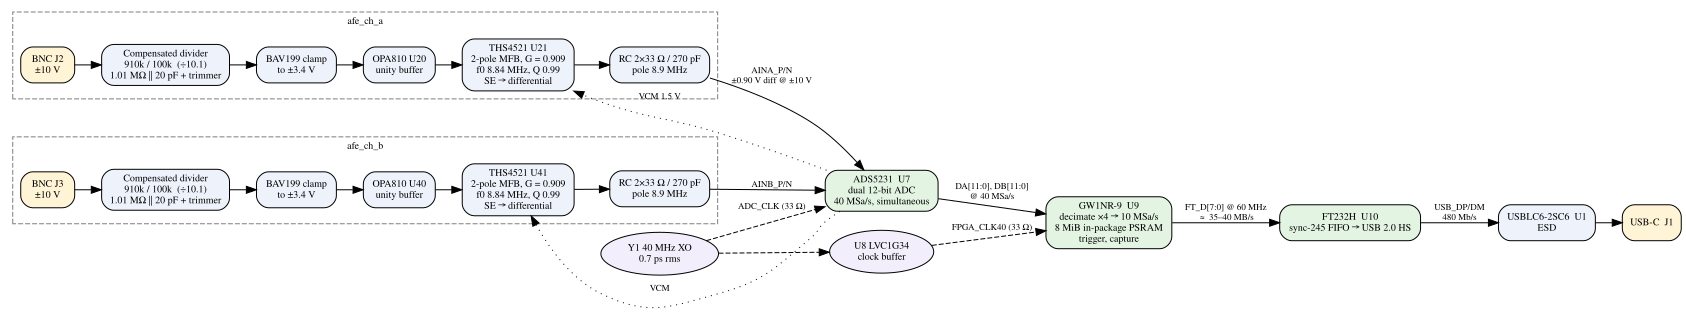

In [2]:
sig = graphviz.Digraph('signal_flow', graph_attr={'rankdir': 'LR', 'fontsize': '10', 'nodesep': '0.25', 'ranksep': '0.35'},
                       node_attr={'shape': 'box', 'style': 'rounded,filled', 'fillcolor': '#eef3fb', 'fontsize': '10'},
                       edge_attr={'fontsize': '9'})

for ch, bnc, u1, u2 in (('A', 'J2', 'U20', 'U21'), ('B', 'J3', 'U40', 'U41')):
    with sig.subgraph(name=f'cluster_afe_{ch}') as c:
        c.attr(label=f'afe_ch_{ch.lower()}', style='dashed', color='gray50')
        c.node(f'bnc{ch}', f'BNC {bnc}\n±10 V', fillcolor='#fff4d6')
        c.node(f'div{ch}', 'Compensated divider\n910k / 100k  (÷10.1)\n1.01 MΩ || 20 pF + trimmer')
        c.node(f'clp{ch}', 'BAV199 clamp\nto ±3.4 V')
        c.node(f'buf{ch}', f'OPA810 {u1}\nunity buffer')
        c.node(f'fda{ch}', f'THS4521 {u2}\n2-pole MFB, G = 0.909\nf0 8.84 MHz, Q 0.99\nSE → differential')
        c.node(f'rc2{ch}', 'RC 2×33 Ω / 270 pF\npole 8.9 MHz')
        c.edges([(f'bnc{ch}', f'div{ch}'), (f'div{ch}', f'clp{ch}'), (f'clp{ch}', f'buf{ch}'),
                 (f'buf{ch}', f'fda{ch}'), (f'fda{ch}', f'rc2{ch}')])

sig.node('xo', 'Y1 40 MHz XO\n0.7 ps rms', shape='ellipse', fillcolor='#f3eefb')
sig.node('buf', 'U8 LVC1G34\nclock buffer', shape='ellipse', fillcolor='#f3eefb')
sig.node('adc', 'ADS5231  U7\ndual 12-bit ADC\n40 MSa/s, simultaneous', fillcolor='#e3f4e3')
sig.node('fpga', 'GW1NR-9  U9\ndecimate ×4 → 10 MSa/s\n8 MiB in-package PSRAM\ntrigger, capture', fillcolor='#e3f4e3')
sig.node('ft', 'FT232H  U10\nsync-245 FIFO → USB 2.0 HS', fillcolor='#e3f4e3')
sig.node('esd', 'USBLC6-2SC6  U1\nESD')
sig.node('usb', 'USB-C  J1', fillcolor='#fff4d6')

sig.edge('rc2A', 'adc', label='AINA_P/N\n±0.90 V diff @ ±10 V')
sig.edge('rc2B', 'adc', label='AINB_P/N')
sig.edge('adc', 'fdaA', label='VCM 1.5 V', style='dotted', constraint='false')
sig.edge('adc', 'fdaB', label='VCM', style='dotted', constraint='false')
sig.edge('xo', 'adc', label='ADC_CLK (33 Ω)', style='dashed')
sig.edge('xo', 'buf', style='dashed')
sig.edge('buf', 'fpga', label='FPGA_CLK40 (33 Ω)', style='dashed')
sig.edge('adc', 'fpga', label='DA[11:0], DB[11:0]\n@ 40 MSa/s')
sig.edge('fpga', 'ft', label='FT_D[7:0] @ 60 MHz\n≈ 35–40 MB/s')
sig.edge('ft', 'esd', label='USB_DP/DM\n480 Mb/s')
sig.edge('esd', 'usb')
sig

### 2.2 Power distribution: USB VBUS → derived rails → consumers

All rails come from switched VBUS (`VBUS_SW`). Digital loads get bucks; the analog chain gets
LDOs. The FT232H is powered from `VBUS_SW` through its own internal 3.3 V regulator (`FT_VCCD`);
only its VCCIO pins sit on `+3V3D`. This was changed after the ERC gate (finding M1) and
**differs from `architecture/net_plan.md`**, which still shows the FT232H on `+3V3D`.

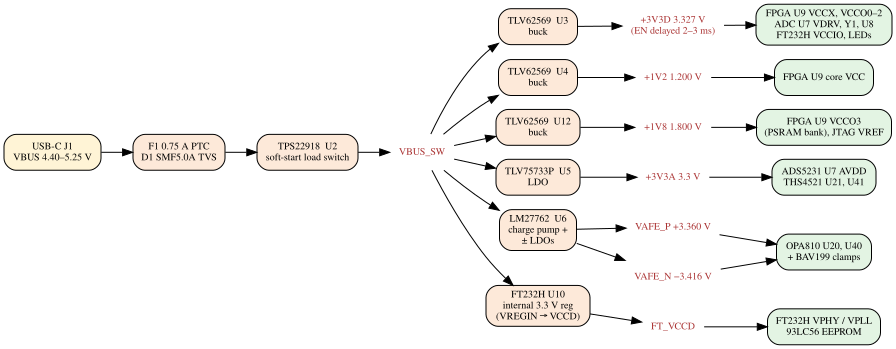

In [3]:
pwr = graphviz.Digraph('power_tree', graph_attr={'rankdir': 'LR', 'fontsize': '10', 'nodesep': '0.2', 'ranksep': '0.45'},
                       node_attr={'shape': 'box', 'style': 'rounded,filled', 'fontsize': '10'},
                       edge_attr={'fontsize': '9'})
reg = {'fillcolor': '#fde9d9'}
rail = {'shape': 'plaintext', 'style': '', 'fontcolor': '#aa3333'}
load = {'fillcolor': '#e3f4e3'}

pwr.node('J1', 'USB-C J1\nVBUS 4.40–5.25 V', fillcolor='#fff4d6')
pwr.node('F1', 'F1 0.75 A PTC\nD1 SMF5.0A TVS', **reg)
pwr.node('U2', 'TPS22918  U2\nsoft-start load switch', **reg)
pwr.node('VB', 'VBUS_SW', **rail)
pwr.edges([('J1', 'F1'), ('F1', 'U2'), ('U2', 'VB')])

# digital
for u, r, v in (('U3', 'V3V3D', '+3V3D 3.327 V\n(EN delayed 2–3 ms)'), ('U4', 'V1V2', '+1V2 1.200 V'), ('U12', 'V1V8', '+1V8 1.800 V')):
    pwr.node(u, f'TLV62569  {u}\nbuck', **reg)
    pwr.node(r, v, **rail)
    pwr.edges([('VB', u), (u, r)])
pwr.node('L_fpio', 'FPGA U9 VCCX, VCCO0–2\nADC U7 VDRV, Y1, U8\nFT232H VCCIO, LEDs', **load)
pwr.node('L_fcore', 'FPGA U9 core VCC', **load)
pwr.node('L_psram', 'FPGA U9 VCCO3\n(PSRAM bank), JTAG VREF', **load)
pwr.edges([('V3V3D', 'L_fpio'), ('V1V2', 'L_fcore'), ('V1V8', 'L_psram')])

# analog
pwr.node('U5', 'TLV75733P  U5\nLDO', **reg)
pwr.node('U6', 'LM27762  U6\ncharge pump +\n± LDOs', **reg)
pwr.node('V3V3A', '+3V3A 3.3 V', **rail)
pwr.node('VP', 'VAFE_P +3.360 V', **rail)
pwr.node('VN', 'VAFE_N −3.416 V', **rail)
pwr.edges([('VB', 'U5'), ('U5', 'V3V3A'), ('VB', 'U6'), ('U6', 'VP'), ('U6', 'VN')])
pwr.node('L_adc', 'ADS5231 U7 AVDD\nTHS4521 U21, U41', **load)
pwr.node('L_buf', 'OPA810 U20, U40\n+ BAV199 clamps', **load)
pwr.edges([('V3V3A', 'L_adc'), ('VP', 'L_buf'), ('VN', 'L_buf')])

# USB bridge
pwr.node('U10reg', 'FT232H U10\ninternal 3.3 V reg\n(VREGIN → VCCD)', **reg)
pwr.node('FTV', 'FT_VCCD', **rail)
pwr.node('L_phy', 'FT232H VPHY / VPLL\n93LC56 EEPROM', **load)
pwr.edges([('VB', 'U10reg'), ('U10reg', 'FTV'), ('FTV', 'L_phy')])
pwr

## 3. Component calculations

Each subsection recomputes the values in the architecture documents from the component values
used in the code, so the numbers can be checked and re-run if a part changes.

### 3.1 Signal scaling and full scale

The ADS5231 full-scale input is 2.02 Vpp differential (±1.01 V) around its 1.5 V common-mode
output. The gain from BNC to ADC pins is the divider ratio times the MFB gain R25/R23.

In [4]:
R_T, R_B = 910e3, 100e3          # R20 / R21
R1, R2 = 1.1e3, 1.0e3            # MFB input / feedback resistors (R23, R25)
ADC_FS_DIFF = 1.01               # ADS5231 ±full scale, differential volts
N_BITS = 12

k_div = R_B / (R_T + R_B)
k_fda = R2 / R1
k_total = k_div * k_fda
fs_in = ADC_FS_DIFF / k_total
lsb_in = 2 * fs_in / 2**N_BITS

print(f'divider ratio        : {k_div:.5f}  (÷{1/k_div:.3f}),  R_in = {eng(R_T + R_B, "Ω")}')
print(f'FDA gain R2/R1       : {k_fda:.4f}')
print(f'total gain           : {k_total:.5f} V/V   (±10 V → ±{10*k_total:.3f} V diff)')
print(f'full scale at BNC    : ±{fs_in:.2f} V   (margin over ±10 V: {100*(fs_in/10-1):.1f} %)')
print(f'LSB referred to BNC  : {eng(lsb_in, "V")}')
print(f'buffer swing at FS   : ±{fs_in*k_div:.3f} V')
# Worst case: ADC gain error −3.5 %, resistor ratio −1 % (net_plan §3)
print(f'worst-case low FS    : ±{fs_in*(1-0.035)*(1-0.01):.2f} V  (must stay > 10 V)')

# THS4521 input common mode: Vx = VOUT × R1/(R1+R2), VOUT = VCM ± half the differential swing
for vout in (1.5 - 0.45, 1.5 + 0.45):
    print(f'FDA input CM at VOUT {vout:.2f} V : {vout*R1/(R1+R2):.3f} V  (THS4521 @3.3 V: −0.1 … 1.8 V)')

divider ratio        : 0.09901  (÷10.100),  R_in = 1.01 MΩ
FDA gain R2/R1       : 0.9091
total gain           : 0.09001 V/V   (±10 V → ±0.900 V diff)
full scale at BNC    : ±11.22 V   (margin over ±10 V: 12.2 %)
LSB referred to BNC  : 5.479 mV
buffer swing at FS   : ±1.111 V
worst-case low FS    : ±10.72 V  (must stay > 10 V)
FDA input CM at VOUT 1.05 V : 0.550 V  (THS4521 @3.3 V: −0.1 … 1.8 V)
FDA input CM at VOUT 1.95 V : 1.021 V  (THS4521 @3.3 V: −0.1 … 1.8 V)


### 3.2 Compensated input divider

A resistive divider loaded by capacitance is flat only when both legs have the same time
constant, `R_T·C_T = R_B·C_B`. That is also what lets a 10× probe (itself a 9 MΩ ‖ C divider) be
compensated against this input.

`C_B` is C22 (200 pF C0G ±5 %) plus the BAV199 (≈ 2 pF), the OPA810 input (≈ 2 pF, **assumed** —
not in its summary; it sits behind R22 = 1 kΩ, small against the ~90 kΩ node impedance) and
≈ 3 pF of board parasitics. `C_T` is C20 (18 pF ±5 %) in parallel with the C21 trimmer (2–6 pF).

In [5]:
C_B_fixed, C_B_tol = 200e-12, 0.05     # C22
C_diode, C_buf, C_par = 2e-12, 2e-12, 3e-12
C_T_fixed, C_T_tol = 18e-12, 0.05      # C20
TRIM_MIN, TRIM_MAX = 2e-12, 6e-12      # C21 STC3MA06

def c_t_needed(c_b):
    return R_B * c_b / R_T

c_b_nom = C_B_fixed + C_diode + C_buf + C_par
lo = c_t_needed(C_B_fixed * (1 - C_B_tol) + C_diode + C_buf + C_par - 2e-12)
hi = c_t_needed(C_B_fixed * (1 + C_B_tol) + C_diode + C_buf + C_par + 2e-12)
avail_lo = C_T_fixed * (1 - C_T_tol) + TRIM_MIN
avail_hi = C_T_fixed * (1 + C_T_tol) + TRIM_MAX
print(f'C_B nominal           : {eng(c_b_nom, "F")}')
print(f'C_T needed            : {eng(c_t_needed(c_b_nom), "F")} nominal, {eng(lo, "F")} … {eng(hi, "F")} worst case')
print(f'C20 + C21 available   : {eng(avail_lo, "F")} … {eng(avail_hi, "F")}')
print(f'headroom              : low {eng(lo - avail_lo, "F")}, high {eng(avail_hi - hi, "F")}')

c_t = c_t_needed(c_b_nom)
print(f'input impedance       : {eng(R_T + R_B, "Ω")} ‖ {eng(c_t * c_b_nom / (c_t + c_b_nom), "F")}  (+ BNC/trace ≈ 2 pF)')
print(f'tilt corner if uncompensated: {eng(1 / (2*np.pi * (R_T*R_B/(R_T+R_B)) * (c_t + c_b_nom)), "Hz")}')

C_B nominal           : 207 pF
C_T needed            : 22.75 pF nominal, 21.43 pF … 24.07 pF worst case
C20 + C21 available   : 19.1 pF … 24.9 pF
headroom              : low 2.329 pF, high 834.1 fF
input impedance       : 1.01 MΩ ‖ 20.5 pF  (+ BNC/trace ≈ 2 pF)
tilt corner if uncompensated: 7.689 kHz


Step response of the divider (what you see when adjusting the trimmer with a 1 kHz square wave).
The edge ratio is `C_T/(C_T+C_B)`, the settled ratio is `R_B/(R_T+R_B)`, and the transition
between them has time constant `(R_T‖R_B)(C_T+C_B)`.

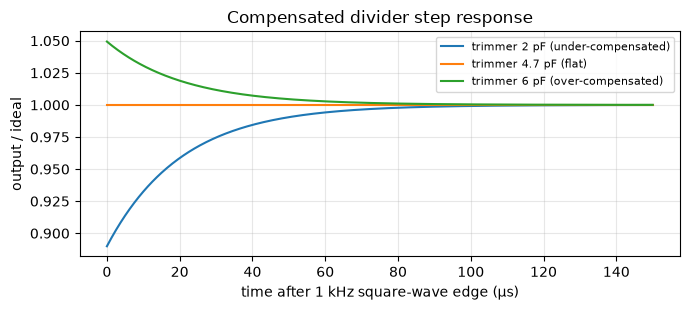

In [6]:
t = np.linspace(0, 150e-6, 600)
fig, ax = plt.subplots(figsize=(7, 3.2))
for trim, lbl in ((TRIM_MIN, 'trimmer 2 pF (under-compensated)'),
                  (c_t - C_T_fixed, f'trimmer {(c_t - C_T_fixed)*1e12:.1f} pF (flat)'),
                  (TRIM_MAX, 'trimmer 6 pF (over-compensated)')):
    C_T = C_T_fixed + trim
    v0 = C_T / (C_T + c_b_nom)
    tau = (R_T * R_B / (R_T + R_B)) * (C_T + c_b_nom)
    v = k_div + (v0 - k_div) * np.exp(-t / tau)
    ax.plot(t * 1e6, v / k_div, label=lbl)
ax.set_xlabel('time after 1 kHz square-wave edge (µs)')
ax.set_ylabel('output / ideal')
ax.set_title('Compensated divider step response')
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 3.3 Overvoltage protection (±50 V)

The BAV199 dual diode clamps the divider node to the ±3.4 V buffer rails. The divider already
divides by 10, so the fault current is limited by R20 (910 kΩ), not by a series resistor.

In [7]:
V_fault = 50.0
VP_AFE, VN_AFE = 3.360, -3.416
V_F = 0.6

print(f'divider node at ±50 V : ±{V_fault * k_div:.2f} V (unclamped)')
print(f'clamp window          : {VN_AFE - V_F:.2f} … {VP_AFE + V_F:.2f} V')
i_f = (V_fault - VP_AFE - V_F) / R_T
print(f'fault current         : {eng(i_f, "A")} into the clamp / VAFE_P rail')
print(f'R20 dissipation       : {eng(i_f**2 * R_T, "W")}')
# Leakage at the ~90 kΩ node vs 1 LSB there
r_node = R_T * R_B / (R_T + R_B)
print(f'BAV199 5 nA × {eng(r_node, "Ω")} = {eng(5e-9 * r_node, "V")}  vs 1 LSB at node {eng(lsb_in * k_div, "V")}')
# Fast edge: capacitive coupling onto ATT before the clamp acts
print(f'50 V edge couples {V_fault * c_t / (c_t + c_b_nom):.1f} V onto ATT (caught by the clamp)')

divider node at ±50 V : ±4.95 V (unclamped)
clamp window          : -4.02 … 3.96 V
fault current         : 50.59 µA into the clamp / VAFE_P rail
R20 dissipation       : 2.329 mW
BAV199 5 nA × 90.1 kΩ = 450.5 µV  vs 1 LSB at node 542.5 µV
50 V edge couples 5.0 V onto ATT (caught by the clamp)


### 3.4 Anti-aliasing filter

The ADC samples at 40 MSa/s and the FPGA decimates by 4 to 10 MSa/s. Anything the analog filter
passes near 40 MHz ± 5 MHz folds straight into the 0–5 MHz output band before the digital filter
can act, so the analog filter must attenuate at the **alias edge, 35 MHz**, while staying flat to
5 MHz. Content between 5 and 35 MHz lands outside the output band and is removed by the
decimation filter in the FPGA.

The filter is **3rd order**:

| Stage | Parts (ch A) | Type |
|---|---|---|
| THS4521 MFB | R23/R24 1.1 kΩ (R1), R25/R26 1 kΩ (R2), R27/R28 270 Ω (R3), C25/C26 100 pF to GND (C1), C27/C28 12 pF (C2) | complex pole pair |
| ADC input RC | R29/R30 33 Ω, C30 270 pF differential | real pole |

Standard MFB low-pass relations, per half-circuit:

$$ f_0 = \frac{1}{2\pi\sqrt{R_2 R_3 C_1 C_2}}, \qquad
   Q = \frac{\sqrt{R_2 R_3 C_1 C_2}}{C_2\,(R_2 + R_3 + R_2 R_3 / R_1)}, \qquad
   H_0 = -\frac{R_2}{R_1} $$

R22 (1 kΩ) with the OPA810 input capacitance makes a further pole far above the band
(≈ 80 MHz with the assumed 2 pF).

In [8]:
AAF = dict(R_T=R_T, C_T=c_t, R_B=R_B, C_B=c_b_nom - C_buf,
           R_S=1e3, C_S=C_buf,
           R1=1.1e3, R2=1.0e3, R3=270.0, C1=100e-12, C2=12e-12,
           R_O=33.0, C_O=270e-12)

def mfb_f0_q(p):
    tau = np.sqrt(p['R2'] * p['R3'] * p['C1'] * p['C2'])
    f0 = 1 / (2 * np.pi * tau)
    Q = tau / (p['C2'] * (p['R2'] + p['R3'] + p['R2'] * p['R3'] / p['R1']))
    return f0, Q

f0, Q = mfb_f0_q(AAF)
f_ro = 1 / (2 * np.pi * 2 * AAF['R_O'] * AAF['C_O'])
f_rs = 1 / (2 * np.pi * AAF['R_S'] * AAF['C_S'])
print(f'MFB f0, Q          : {eng(f0, "Hz")}, Q = {Q:.3f}   (Butterworth Q = 0.707)')
print(f'ADC-input RC pole  : {eng(f_ro, "Hz")}')
print(f'buffer-input pole  : {eng(f_rs, "Hz")}  (assumed 2 pF)')

MFB f0, Q          : 8.842 MHz, Q = 0.990   (Butterworth Q = 0.707)
ADC-input RC pole  : 8.931 MHz
buffer-input pole  : 79.58 MHz  (assumed 2 pF)


Two models of the complete chain from BNC to ADC pins:

1. **Ideal cascade** — the product of the stage responses above (ideal amplifiers, no loading).
2. **Nodal model** — a node-voltage (MNA) solution of the circuit as wired in the code, including
   the divider, both halves of the MFB, the OPA810 (GBW 70 MHz) and the THS4521 (GBW 145 MHz,
   A₀ = 100 dB, both assumed single-pole). The FDA is modelled by
   `Vop − Von = A(s)·(V(VIN+) − V(VIN−))` and `Vop + Von = 0` (AC, VOCM held constant).

In [9]:
def h_cascade(f, p=AAF):
    s = 2j * np.pi * np.asarray(f)
    f0, Q = mfb_f0_q(p); w0 = 2 * np.pi * f0
    return (1 / (1 + s * p['R_S'] * p['C_S'])
            / (1 + s / (w0 * Q) + (s / w0)**2)
            / (1 + s * 2 * p['R_O'] * p['C_O']))


def h_nodal(f, p=AAF, gbw_buf=70e6, gbw_fda=145e6, a0=1e5):
    # Nodes: ATT, BUF_IN, BUF_OUT, MS, MR, FIP, FIN, FOP, FON, AIN_P, AIN_N
    ATT, BI, BO, MS, MR, FIP, FIN, FOP, FON, AP, AN = range(11)
    GND, SRC = -1, -2
    s = 2j * np.pi * f
    Y = np.zeros((11, 11), complex); b = np.zeros(11, complex)

    def y(i, j, yy):                      # admittance from node i to node j (KCL row i)
        Y[i, i] += yy
        if j >= 0:
            Y[i, j] -= yy
        elif j == SRC:
            b[i] += yy                    # 1 V source at the BNC

    yT, yB, yS = 1/p['R_T'] + s*p['C_T'], 1/p['R_B'] + s*p['C_B'], 1/p['R_S']
    y(ATT, SRC, yT); y(ATT, GND, yB); y(ATT, BI, yS)
    y(BI, ATT, yS); y(BI, GND, s*p['C_S'])
    Y[BO, BO], Y[BO, BI] = 1, -1 / (1 + s / (2*np.pi*gbw_buf))          # OPA810 follower
    # signal leg: BO -R1- MS, MS -C1- GND, MS -R2- FON, MS -R3- FIP, FIP -C2- FON
    # ref leg:   GND -R1- MR, MR -C1- GND, MR -R2- FOP, MR -R3- FIN, FIN -C2- FOP
    for m, fi, fo_fb, src in ((MS, FIP, FON, BO), (MR, FIN, FOP, GND)):
        y(m, src, 1/p['R1']); y(m, GND, s*p['C1']); y(m, fi, 1/p['R3']); y(m, fo_fb, 1/p['R2'])
        y(fi, m, 1/p['R3']); y(fi, fo_fb, s*p['C2'])
    A = a0 / (1 + s * a0 / (2*np.pi*gbw_fda))
    Y[FOP, :] = 0; Y[FOP, FOP], Y[FOP, FON], Y[FOP, FIP], Y[FOP, FIN] = 1, -1, -A, A
    Y[FON, :] = 0; Y[FON, FOP], Y[FON, FON] = 1, 1
    y(AP, FOP, 1/p['R_O']); y(AP, AN, s*p['C_O'])
    y(AN, FON, 1/p['R_O']); y(AN, AP, s*p['C_O'])
    v = np.linalg.solve(Y, b)
    return v[AP] - v[AN]


h_nodal_v = np.vectorize(h_nodal, excluded={'p'})
H0 = abs(h_nodal(1.0))
print(f'nodal DC gain: {H0:.5f} V/V  (hand calc {k_total:.5f})')

def db(h):
    return 20 * np.log10(np.abs(h))

def f_3db(fn):
    return brentq(lambda x: db(fn(x)) + 3, 1e6, 3e7)

hn = lambda f: h_nodal(f) / H0
print(f'-3 dB: cascade {eng(f_3db(h_cascade), "Hz")}, nodal {eng(f_3db(hn), "Hz")}')
print(f'\n{"f":>9}  {"cascade":>8}  {"nodal":>8}')
for f in (1e6, 4e6, 5e6, 10e6, 20e6, 35e6, 40e6):
    print(f'{eng(f, "Hz"):>9}  {db(h_cascade(f)):7.2f}   {db(hn(f)):7.2f}  dB')

nodal DC gain: 0.09001 V/V  (hand calc 0.09001)
-3 dB: cascade 8.768 MHz, nodal 8.248 MHz

        f   cascade     nodal
    1 MHz    -0.00      0.03  dB
    4 MHz    -0.06      0.36  dB
    5 MHz    -0.17      0.34  dB
   10 MHz    -5.01     -6.76  dB
   20 MHz   -21.52    -24.56  dB
   35 MHz   -36.54    -40.29  dB
   40 MHz   -40.23    -44.26  dB


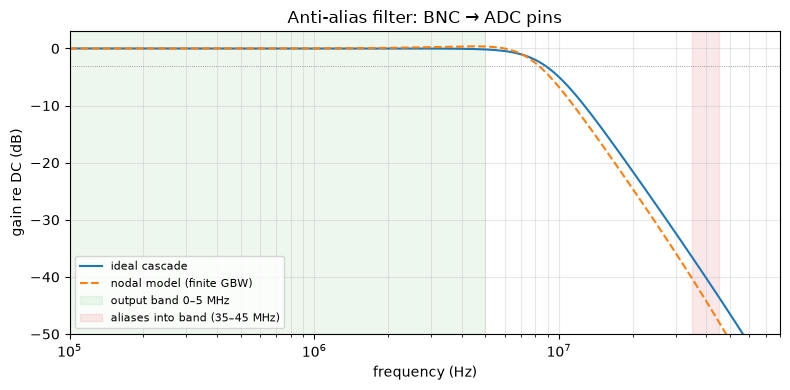

In [10]:
f = np.logspace(5, np.log10(80e6), 400)
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(f, db(h_cascade(f)), label='ideal cascade')
ax.semilogx(f, db(h_nodal_v(f) / H0), '--', label='nodal model (finite GBW)')
ax.axvspan(1e5, 5e6, color='tab:green', alpha=0.08, label='output band 0–5 MHz')
ax.axvspan(35e6, 45e6, color='tab:red', alpha=0.10, label='aliases into band (35–45 MHz)')
ax.axhline(-3, color='gray', lw=0.6, ls=':')
ax.set_xlim(1e5, 80e6); ax.set_ylim(-50, 3)
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('gain re DC (dB)')
ax.set_title('Anti-alias filter: BNC → ADC pins')
ax.grid(which='both', alpha=0.3); ax.legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()

Tolerance check: Monte-Carlo over the filter parts (R ±1 %, C ±5 % C0G, independent for each
half of the differential MFB is not modelled — both halves share one draw) using the nodal model.

In [11]:
rng = np.random.default_rng(1)
keys_r = ('R1', 'R2', 'R3', 'R_O')
keys_c = ('C1', 'C2', 'C_O')
res = []
for _ in range(200):
    p = dict(AAF)
    for k in keys_r:
        p[k] = AAF[k] * (1 + rng.uniform(-0.01, 0.01))
    for k in keys_c:
        p[k] = AAF[k] * (1 + rng.uniform(-0.05, 0.05))
    h0 = abs(h_nodal(1.0, p))
    g = lambda x: h_nodal(x, p) / h0
    res.append((f_3db(g), db(g(5e6)), db(g(35e6)), max(db(g(x)) for x in np.linspace(1e5, 5e6, 20))))
res = np.array(res)
for i, name, unit in ((0, '-3 dB frequency', 'MHz'), (1, 'gain @ 5 MHz', 'dB'),
                      (2, 'gain @ 35 MHz', 'dB'), (3, 'peaking in 0–5 MHz', 'dB')):
    col = res[:, i] / (1e6 if unit == 'MHz' else 1)
    print(f'{name:20s}: min {col.min():7.2f}  mean {col.mean():7.2f}  max {col.max():7.2f}  {unit}')

-3 dB frequency     : min    7.90  mean    8.25  max    8.66  MHz
gain @ 5 MHz        : min    0.06  mean    0.34  max    0.60  dB
gain @ 35 MHz       : min  -41.27  mean  -40.28  max  -39.11  dB
peaking in 0–5 MHz  : min    0.16  mean    0.38  max    0.61  dB


**Result and caveats.**

- `architecture/net_plan.md` quotes −3 dB at 8.80 MHz, −0.16 dB at 5 MHz and −35.8 dB at 35 MHz.
  The ideal cascade reproduces that (8.77 MHz, −0.17 dB, −36.5 dB).
- The nodal model, with the THS4521's finite GBW, shows **≈ 0.35 dB of in-band peaking** around
  4–5 MHz and a lower −3 dB point (≈ 8.25 MHz): the amplifier's phase lag raises the MFB's
  effective Q above the designed 0.99. It also gives more rejection at 35 MHz (≈ −40 dB). The
  architecture's nodal solve evidently used ideal amplifiers. Neither model has been checked
  against SPICE or measurement; the GBW figures are single-pole approximations.
- 36–40 dB of rejection at the alias edge is ~6 bits — well short of the 74 dB a 12-bit
  converter can resolve. Energy at 35–45 MHz at the BNC aliases into the band with only that
  much rejection. This is a documented limit (design_risks A6), not a defect.
- The ADC input capacitance and the OPA810 input capacitance are assumptions.
- In-band droop is to be equalised in the FPGA decimation FIR (≥ 70 dB stopband from 6 MHz);
  that HDL does not exist yet.

### 3.5 Data rates, capture depth and USB upload

In [12]:
F_ADC = 40e6; DECIM = 4; CH = 2; BYTES = 2      # 12-bit samples stored as 16-bit words
PSRAM = 8 * 2**20                                # 64 Mbit
USB_RATE = (30e6, 40e6)                          # FT232H sync-FIFO, practical range

f_out = F_ADC / DECIM
rate_store = f_out * CH * BYTES
print(f'ADC → FPGA          : 2 × 12 bit @ {eng(F_ADC, "Sa/s")} = {eng(F_ADC*24, "b/s")} parallel')
print(f'output rate         : {eng(f_out, "Sa/s")} per channel')
print(f'PSRAM write rate    : {eng(rate_store, "B/s")}  (raw device 664 MB/s; IP efficiency unverified, K3)')
print(f'capture depth       : {PSRAM / rate_store:.4f} s at 10 MSa/s (need ≥ 0.1 s)')
need = 0.1 * rate_store
print(f'upload of 0.1 s     : {eng(need, "B")} in {need/USB_RATE[1]:.2f}–{need/USB_RATE[0]:.2f} s')
print(f'streaming instead   : needs {eng(rate_store, "B/s")} sustained — at/above USB 2.0 HS practice')

ADC → FPGA          : 2 × 12 bit @ 40 MSa/s = 960 Mb/s parallel
output rate         : 10 MSa/s per channel
PSRAM write rate    : 40 MB/s  (raw device 664 MB/s; IP efficiency unverified, K3)
capture depth       : 0.2097 s at 10 MSa/s (need ≥ 0.1 s)
upload of 0.1 s     : 4 MB in 0.10–0.13 s
streaming instead   : needs 40 MB/s sustained — at/above USB 2.0 HS practice


### 3.6 Regulator output voltages

TLV62569 bucks: `Vout = 0.6 V · (1 + R_top/R_bot)` (VFB 0.588–0.612 V). LM27762: positive side
`VP = 1.2 V · (R_top + R_bot)/R_bot`, negative side `VN = −1.22 V · (R_top + R_bot)/R_bot`
(R_bot ≥ 50 kΩ required). Worst case includes the reference tolerance and 1 % resistors.

In [13]:
def divider_out(vref, r_top, r_bot, sign=1, vref_tol=0.02, r_tol=0.01):
    nom = vref * (r_top + r_bot) / r_bot
    hi = vref * (1 + vref_tol) * (1 + r_top * (1 + r_tol) / (r_bot * (1 - r_tol)))
    lo = vref * (1 - vref_tol) * (1 + r_top * (1 - r_tol) / (r_bot * (1 + r_tol)))
    return sign * nom, sign * lo, sign * hi

rails = [
    ('+3V3D  (U3, R5/R6)',   0.6,  100e3, 22e3,  1, 0.02,  'FPGA VCCX/VCCIO, ADC VDRV, FT VCCIO'),
    ('+1V2   (U4, R7/R8)',   0.6,  100e3, 100e3, 1, 0.02,  'GW1NR VCC 1.14–1.26 V'),
    ('+1V8   (U12, R14/R15)', 0.6, 200e3, 100e3, 1, 0.02,  'GW1NR VCCO3 1.71–1.89 V'),
    ('VAFE_P (U6, R10/R11)', 1.2,  180e3, 100e3, 1, 0.015, 'OPA810 V+'),
    ('VAFE_N (U6, R12/R13)', 1.22, 180e3, 100e3, -1, 0.015, 'OPA810 V−'),
]
out = {}
for name, vref, rt, rb, sg, tol, note in rails:
    nom, lo, hi = divider_out(vref, rt, rb, sg, tol)
    out[name.split()[0]] = (nom, lo, hi)
    print(f'{name:22s} {nom:+.3f} V  ({lo:+.3f} … {hi:+.3f})   {note}')
print('+3V3A  (U5, fixed)     +3.300 V')

vp_hi, vn_lo = out['VAFE_P'][2], out['VAFE_N'][2]
print(f'\nOPA810 worst total supply: {vp_hi - vn_lo:.3f} V (range 4.75–27 V)')
v3d_hi = out['+3V3D'][2]
print(f'ADS5231 |AVDD − VDRV| worst: {abs(v3d_hi - 3.3*0.98):.3f} V (abs max 0.3 V, LDO ±2 % assumed)')

+3V3D  (U3, R5/R6)     +3.327 V  (+3.208 … +3.450)   FPGA VCCX/VCCIO, ADC VDRV, FT VCCIO
+1V2   (U4, R7/R8)     +1.200 V  (+1.164 … +1.236)   GW1NR VCC 1.14–1.26 V
+1V8   (U12, R14/R15)  +1.800 V  (+1.741 … +1.861)   GW1NR VCCO3 1.71–1.89 V
VAFE_P (U6, R10/R11)   +3.360 V  (+3.267 … +3.455)   OPA810 V+
VAFE_N (U6, R12/R13)   -3.416 V  (-3.322 … -3.512)   OPA810 V−
+3V3A  (U5, fixed)     +3.300 V

OPA810 worst total supply: 6.967 V (range 4.75–27 V)
ADS5231 |AVDD − VDRV| worst: 0.216 V (abs max 0.3 V, LDO ±2 % assumed)


### 3.7 Power budget (as built)

Load currents are from `architecture/design_risks.md` P1; several are **assumptions** (FPGA core
150 mA = K5, +1V8 100 mA = K10). P1 placed the FT232H's 112 mA (52 mA regulator + 60 mA PHY,
max) on `+3V3D` through a buck. In 5 V mode that current comes **straight from VBUS through the
FT232H's internal linear regulator**, so it is recomputed here. Linear regulators draw their output
current from VBUS; bucks draw `P_out / η`.

In [14]:
# (name, kind, V_out, I_max, efficiency)
loads = [
    ('+3V3A  TLV75733P LDO',        'ldo',  3.3,   92.1e-3, None),
    ('VAFE_P/N LM27762 (VIN)',      'ldo',  None,  24.4e-3, None),
    ('FT232H internal reg (5 V mode)', 'ldo', 3.3, 112e-3,  None),
    ('+3V3D  TLV62569 buck',        'buck', 3.327, 195e-3 - 112e-3, 0.88),
    ('+1V2   TLV62569 buck (K5)',   'buck', 1.2,   150e-3,  0.80),
    ('+1V8   TLV62569 buck (K10)',  'buck', 1.8,   100e-3,  0.82),
]
P_SWITCH = 0.05          # TPS22918 + PTC, W
LIMIT = 0.500
for vbus in (4.4, 5.0):
    i_lin = sum(i for _, k, _, i, _ in loads if k == 'ldo')
    p_sw = sum(v * i / e for _, k, v, i, e in loads if k == 'buck') + P_SWITCH
    i_tot = i_lin + p_sw / vbus
    print(f'VBUS {vbus:.2f} V: linear {i_lin*1e3:.0f} mA + switching {p_sw:.3f} W/{vbus} V = '
          f'{i_tot*1e3:.0f} mA ({i_tot*vbus:.2f} W);  ×1.25 margin = {1.25*i_tot*1e3:.0f} mA')

# The same budget with the FT232H on +3V3D (design_risks P1 as written, 3.3 V mode)
i_old = 92.1e-3 + 24.4e-3 + (3.327*0.195/0.88 + 0.225 + 0.220 + P_SWITCH) / 4.4
print(f'\nP1 as written (FT232H on +3V3D): {i_old*1e3:.0f} mA @4.4 V, ×1.25 = {1.25*i_old*1e3:.0f} mA')
print('→ 5 V mode costs ≈ 16 mA at 4.4 V and pushes the ×1.25 line just past 500 mA.')
print('  Without the margin factor the board stays under 500 mA; on a USB-C host advertising')
print('  1.5 A (the board has 5.1 kΩ Rd on CC) there is ample headroom.')

# LDO dissipation — the hottest small part
p5 = (5.25 - 3.3) * 92.1e-3
print(f'\nTLV75733P dissipation: {p5*1e3:.0f} mW → Tj ≈ {70 + p5*231:.0f} °C at 70 °C ambient, θJA 231 °C/W (limit 125 °C)')

VBUS 4.40 V: linear 228 mA + switching 0.808 W/4.4 V = 412 mA (1.81 W);  ×1.25 margin = 515 mA
VBUS 5.00 V: linear 228 mA + switching 0.808 W/5.0 V = 390 mA (1.95 W);  ×1.25 margin = 488 mA

P1 as written (FT232H on +3V3D): 397 mA @4.4 V, ×1.25 = 496 mA
→ 5 V mode costs ≈ 16 mA at 4.4 V and pushes the ×1.25 line just past 500 mA.
  Without the margin factor the board stays under 500 mA; on a USB-C host advertising
  1.5 A (the board has 5.1 kΩ Rd on CC) there is ample headroom.

TLV75733P dissipation: 180 mW → Tj ≈ 111 °C at 70 °C ambient, θJA 231 °C/W (limit 125 °C)


### 3.8 Miscellaneous values

In [15]:
# FT232H 12 MHz crystal load caps (CL 20 pF)
c_ser = 33e-12 / 2
print(f'Y2 load: 33 pF ‖ 33 pF series = {eng(c_ser, "F")} + 3–5 pF stray = '
      f'{eng(c_ser + 3e-12, "F")} … {eng(c_ser + 5e-12, "F")}  (CL 20 pF)')

# LEDs D80/D81 through 1 kΩ from 3.3 V
print(f'LED current: (3.327 − 2.0 V) / 1 kΩ = {eng((3.327 - 2.0) / 1e3, "A")}')

# Clock-jitter budget for 12-bit-class SNR at 5 MHz
SNR_ADC = 70.7
for tj in (0.7e-12, 1e-12, 5.04e-12, 50e-12):
    snr_j = -20*np.log10(2*np.pi*5e6*tj)
    tot = -10*np.log10(10**(-SNR_ADC/10) + 10**(-snr_j/10))
    print(f'  jitter {tj*1e12:5.2f} ps rms → SNR_j {snr_j:5.1f} dB, with ADC {tot:5.2f} dB '
          f'(ENOB {(tot-1.76)/6.02:.2f})')
print('  Y1 OT322540MJBA4SL: 0.7 ps max (12 kHz–20 MHz). The FPGA PLL is kept out of the ADC clock path.')

# ADC → FPGA capture window without DVA/DVB (design_risks T4)
t_lo, t_hi = 14.8e-9, 25.0e-9
print(f'ADC data window at 40 MSa/s: {eng(t_lo, "s")} … {eng(t_hi, "s")} after CLK↑ = {eng(t_hi - t_lo, "s")}')

# Load-switch inrush (TPS22918, CT = 1 nF → tR 2.54 ms at 5 V); capacitance counted in §6.3
print('TPS22918 rise time with CT = 1 nF: 2.54 ms (datasheet) — inrush computed from the netlist in §6.3')

Y2 load: 33 pF ‖ 33 pF series = 16.5 pF + 3–5 pF stray = 19.5 pF … 21.5 pF  (CL 20 pF)
LED current: (3.327 − 2.0 V) / 1 kΩ = 1.327 mA
  jitter  0.70 ps rms → SNR_j  93.2 dB, with ADC 70.68 dB (ENOB 11.45)
  jitter  1.00 ps rms → SNR_j  90.1 dB, with ADC 70.65 dB (ENOB 11.44)
  jitter  5.04 ps rms → SNR_j  76.0 dB, with ADC 69.58 dB (ENOB 11.27)
  jitter 50.00 ps rms → SNR_j  56.1 dB, with ADC 55.93 dB (ENOB 9.00)
  Y1 OT322540MJBA4SL: 0.7 ps max (12 kHz–20 MHz). The FPGA PLL is kept out of the ADC clock path.
ADC data window at 40 MSa/s: 14.8 ns … 25 ns after CLK↑ = 10.2 ns
TPS22918 rise time with CT = 1 nF: 2.54 ms (datasheet) — inrush computed from the netlist in §6.3


## 4. Part sourcing

All parts were sourced from JLCPCB/LCSC stock (`sourcing/sourced_bom.csv`, revision 3). The
active parts and connectors:

In [16]:
import pandas as pd
bom = pd.read_csv(PROJ / 'sourcing' / 'sourced_bom.csv')
ics = bom[bom.refdes.str.match(r'^(U|Y|J)\d')][['refdes', 'mpn', 'lcsc', 'package', 'tier', 'stock', 'notes']]
display(ics.style.hide(axis='index'))
print(bom.tier.value_counts().to_string())

refdes,mpn,lcsc,package,tier,stock,notes
J1,TYPE-C-31-M-12,C165948,USB-C-SMD-16P,Extended,89797,USB 2.0 only
U1,USBLC6-2SC6,C2687116,SOT-23-6,Extended,150192,nan
U2,TPS22918DBVR,C131941,SOT-23-6,Extended,44958,symbol generated by datasheet-librarian (symbols/dual_adc_usb.kicad_sym)
"U3,U4,U12",TLV62569DBVR,C141836,SOT-23-5,Extended,108275,3V3D / 1V2 / 1V8 bucks;
U5,TLV75733PDBVR,C485517,SOT-23-5,Extended,194991,nan
U6,LM27762DSSR,C473398,WSON-12-3x2mm,Extended,11277,nan
"J2,J3",KH-BNC50-3511,C2837587,BNC-RA-THT,Extended,4742,"custom FP footprints/ProjectLocal.pretty/KH-BNC50-3511.kicad_mod from KH drawing (KiCad BNC footprints are 4-leg/different spacing, not drawing-compatible); second source DOSIN-801-0038 (same KH-801-0038 family, verify drawing)"
"U20,U40",OPA810IDBVR,C2833513,SOT-23-5,Extended,3280,verify pinout K1
"U21,U41",THS4521IDGKR,C170157,MSOP-8,Extended,17791,nan
U7,ADS5231IPAGT,C2670079,TQFP-64-10x10,Extended,235,"symbol generated (symbols/dual_adc_usb.kicad_sym); DVA/DVB/OVRA/OVRB NC; critical path, single source"


tier
Extended     31
Basic        26
Preferred     2


## 5. Design blocks (SKiDL)

Each block is an `@SubCircuit` function whose arguments are its interface nets. Nets local to a
block are created inside it. Each cell starts with `%%block <name>` (defined in the setup cell),
which runs it in its own namespace, as its `.py` module would be. Blocks never import each other; the top-level assembly (§6) creates
the interface nets and wires the blocks together. Execution order below follows the power path,
then the signal path.

### 5.1 USB power input

USB-C receptacle (USB 2.0 data only) with 5.1 kΩ Rd on each CC, a 0.75 A PTC and SMF5.0A TVS on VBUS, USBLC6 ESD on D+/D−, and a TPS22918 load switch whose 1 nF CT gives a 2.5 ms rise to keep inrush into the downstream capacitance low (§6.3). Produces `VBUS_SW`.

In [17]:
%%block usb_power_in
"""USB Power In — USB-C (USB 2.0) receptacle, PTC fuse, TVS, data-line ESD, soft-start load switch
Block from: architecture/block_diagram.md
Interface nets: VBUS_SW, USB_DP, USB_DM, GND
"""

_R = 'Resistor_SMD:R_0402_1005Metric'


@SubCircuit
def usb_power_in(vbus_sw, usb_dp, usb_dm, gnd):
    """J1 USB-C sink (Rd 5.1k on CC1/CC2) -> VBUS -> F1 PTC 0.75 A -> VBUS_F.
    VBUS_F: D1 SMF5.0A TVS, U1 USBLC6 VBUS ref, C1 4.7 uF (only <=10 uF ahead of the switch).
    U2 TPS22918 load switch: VIN = VBUS_F, ON via R3 10k from VBUS_F, CT = C2 1 nF (tR 2.54 ms),
    QOD tied to VOUT (internal discharge), VOUT -> vbus_sw with C3 10 uF.
    Drives vbus_sw (U2.VOUT is a power output). usb_dp/usb_dm are bidirectional passthrough.
    Refs J1, U1, U2, F1, D1, R1, R2, R3, C1, C2, C3."""
    vbus = Net('VBUS')
    vbus_f = Net('VBUS_F')
    # The USB host is the source of VBUS_F (through J1 and F1, both passive), so the
    # net is marked as a power source here; the top level cannot reach this internal net.
    vbus_f.drive = POWER
    usb_on = Net('USB_ON')
    usb_ct = Net('USB_CT')
    cc1 = Net('CC1')
    cc2 = Net('CC2')

    j1 = Part('Connector', 'USB_C_Receptacle_USB2.0_16P', ref='J1', value='USB-C 16P',
              footprint='Connector_USB:USB_C_Receptacle_HRO_TYPE-C-31-M-12',
              MPN='TYPE-C-31-M-12', LCSC='C165948')
    j1['VBUS'] += vbus                    # A4, A9, B4, B9
    j1['GND'] += gnd                      # A1, A12, B1, B12
    j1['SHIELD'] += gnd                   # S1
    j1['A5'] += cc1                       # CC1
    j1['B5'] += cc2                       # CC2
    j1['A6', 'B6'] += usb_dp              # D+
    j1['A7', 'B7'] += usb_dm              # D-
    j1['A8', 'B8'] += NC                  # SBU1/SBU2 unused (USB 2.0)

    # UFP Rd pull-downs, one per CC (never tie CCs together)
    r1 = Part('Device', 'R', ref='R1', value='5.1k', footprint=_R, MPN='0402WGF5101TCE', LCSC='C25905')
    r2 = Part('Device', 'R', ref='R2', value='5.1k', footprint=_R, MPN='0402WGF5101TCE', LCSC='C25905')
    cc1 & r1 & gnd
    cc2 & r2 & gnd

    f1 = Part('Device', 'Polyfuse', ref='F1', value='0.75A',
              footprint='Fuse:Fuse_1206_3216Metric', MPN='SMD1206P075TF', LCSC='C20987')
    vbus & f1 & vbus_f

    # SMF5.0A unidirectional TVS: pin 1 = K -> VBUS_F, pin 2 = A -> GND (by number)
    d1 = Part('Diode', 'SMF5V0A', ref='D1', value='SMF5.0A',
              footprint='Diode_SMD:D_SOD-123F', MPN='SMF5.0A', LCSC='C19077497')
    d1[1] += vbus_f
    d1[2] += gnd

    # USBLC6-2SC6 flow-through: I/O1 (1,6) on D+, I/O2 (3,4) on D-
    u1 = Part('Power_Protection', 'USBLC6-2SC6', ref='U1', value='USBLC6-2SC6',
              footprint='Package_TO_SOT_SMD:SOT-23-6', MPN='USBLC6-2SC6', LCSC='C2687116')
    u1[1, 6] += usb_dp
    u1[3, 4] += usb_dm
    u1['VBUS'] += vbus_f
    u1['GND'] += gnd

    c1 = Part('Device', 'C', ref='C1', value='4.7uF', footprint='Capacitor_SMD:C_0603_1608Metric',
              MPN='CL10A475KO8NNNC', LCSC='C19666')
    vbus_f & c1 & gnd

    u2 = Part('dual_adc_usb', 'TPS22918DBVR', ref='U2', value='TPS22918DBVR',
              footprint='Package_TO_SOT_SMD:SOT-23-6', MPN='TPS22918DBVR', LCSC='C131941')
    u2['VIN'] += vbus_f
    u2['GND'] += gnd
    u2['ON'] += usb_on
    u2['CT'] += usb_ct
    u2['QOD'] += vbus_sw                  # internal quick-output-discharge enabled
    u2['VOUT'] += vbus_sw

    r3 = Part('Device', 'R', ref='R3', value='10k', footprint=_R, MPN='0402WGF1002TCE', LCSC='C25744')
    vbus_f & r3 & usb_on                  # ON high whenever VBUS present (VIH 1.0 V)

    c2 = Part('Device', 'C', ref='C2', value='1nF', footprint='Capacitor_SMD:C_0402_1005Metric',
              MPN='0402B102K500NT', LCSC='C1523')
    usb_ct & c2 & gnd                     # tR 2.54 ms @ 5 V

    c3 = Part('Device', 'C', ref='C3', value='10uF', footprint='Capacitor_SMD:C_0603_1608Metric',
              MPN='CL10A106KP8NNNC', LCSC='C19702')
    vbus_sw & c3 & gnd

### 5.2 Digital power

Three TLV62569 bucks make +3V3D, +1V2 (FPGA core) and +1V8 (FPGA bank 3 / PSRAM). +1V2 and +1V8 start together; +3V3D is held off 2–3 ms by an RC on its EN pin to meet the Gowin power-up rules (design_risks P3). Feedback values are checked in §3.6.

In [18]:
%%block pwr_digital
"""Power Digital — three TLV62569DBV bucks from VBUS_SW: +3V3D (EN-delayed), +1V2, +1V8
Block from: architecture/block_diagram.md
Interface nets: VBUS_SW, +3V3D, +1V2, +1V8, GND
"""

_R = 'Resistor_SMD:R_0402_1005Metric'
_C0402 = 'Capacitor_SMD:C_0402_1005Metric'
_C0603 = 'Capacitor_SMD:C_0603_1608Metric'
_C0805 = 'Capacitor_SMD:C_0805_2012Metric'
_L = 'Inductor_SMD:L_Changjiang_FNR4020S'


def _r(ref, value, mpn, lcsc):
    return Part('Device', 'R', ref=ref, value=value, footprint=_R, MPN=mpn, LCSC=lcsc)


def _c(ref, value, fp, mpn, lcsc):
    return Part('Device', 'C', ref=ref, value=value, footprint=fp, MPN=mpn, LCSC=lcsc)


def _buck(ref, lref, vin, en, sw, fb, vout, gnd):
    u = Part('Regulator_Switching', 'TLV62569DBV', ref=ref, value='TLV62569DBVR',
             footprint='Package_TO_SOT_SMD:SOT-23-5', MPN='TLV62569DBVR', LCSC='C141836')
    u['VIN'] += vin
    u['EN'] += en
    u['GND'] += gnd
    u['SW'] += sw
    u['FB'] += fb
    l = Part('Device', 'L', ref=lref, value='2.2uH', footprint=_L,
             MPN='FHD4020S-2R2MT', LCSC='C602029')
    sw & l & vout
    return u


@SubCircuit
def pwr_digital(vbus_sw, v3v3d, v1v2, v1v8, gnd):
    """U3 -> v3v3d (R5 100k / R6 22k -> 3.327 V), EN via R9 100k / C8 100 nF RC delay (2.0-3.2 ms).
    U4 -> v1v2 (R7 100k / R8 100k -> 1.200 V), EN = vbus_sw.
    U12 -> v1v8 (R14 200k / R15 100k -> 1.800 V), EN = vbus_sw (VCC and VCCO3 ramp together, UG284).
    Inputs: C4/C6/C9 10 uF on vbus_sw. Outputs: C5/C7/C17 22 uF.
    Drives v3v3d, v1v2, v1v8 (marked .drive = POWER here: the regulator's PWROUT pin is SW,
    which reaches the rail only through the passive inductor). Consumes vbus_sw, gnd.
    Assumption K10: +1V8 load <= 100 mA (unverified, accepted)."""
    for rail in (v3v3d, v1v2, v1v8):
        rail.drive = POWER

    sw_3v3, fb_3v3, en_3v3 = Net('SW_3V3'), Net('FB_3V3'), Net('EN_3V3')
    sw_1v2, fb_1v2 = Net('SW_1V2'), Net('FB_1V2')
    sw_1v8, fb_1v8 = Net('SW_1V8'), Net('FB_1V8')

    # +3V3D (U3), enable delayed by R9/C8 so it follows +1V2/+1V8
    _buck('U3', 'L1', vbus_sw, en_3v3, sw_3v3, fb_3v3, v3v3d, gnd)
    v3v3d & _r('R5', '100k', '0402WGF1003TCE', 'C25741') & fb_3v3 & _r('R6', '22k', '0402WGF2202TCE', 'C25768') & gnd
    vbus_sw & _r('R9', '100k', '0402WGF1003TCE', 'C25741') & en_3v3 & _c('C8', '100nF', _C0402, 'CL05B104KO5NNNC', 'C1525') & gnd
    vbus_sw & _c('C4', '10uF', _C0603, 'CL10A106KP8NNNC', 'C19702') & gnd
    v3v3d & _c('C5', '22uF', _C0805, 'CL21A226MAQNNNE', 'C45783') & gnd

    # +1V2 (U4)
    _buck('U4', 'L2', vbus_sw, vbus_sw, sw_1v2, fb_1v2, v1v2, gnd)
    v1v2 & _r('R7', '100k', '0402WGF1003TCE', 'C25741') & fb_1v2 & _r('R8', '100k', '0402WGF1003TCE', 'C25741') & gnd
    vbus_sw & _c('C6', '10uF', _C0603, 'CL10A106KP8NNNC', 'C19702') & gnd
    v1v2 & _c('C7', '22uF', _C0805, 'CL21A226MAQNNNE', 'C45783') & gnd

    # +1V8 (U12)
    _buck('U12', 'L3', vbus_sw, vbus_sw, sw_1v8, fb_1v8, v1v8, gnd)
    v1v8 & _r('R14', '200k', '0402WGF2003TCE', 'C25764') & fb_1v8 & _r('R15', '100k', '0402WGF1003TCE', 'C25741') & gnd
    vbus_sw & _c('C9', '10uF', _C0603, 'CL10A106KP8NNNC', 'C19702') & gnd
    v1v8 & _c('C17', '22uF', _C0805, 'CL21A226MAQNNNE', 'C45783') & gnd

### 5.3 Analog power

A TLV75733P LDO makes +3V3A for the ADC and FDAs. An LM27762 (charge-pump inverter plus positive and negative LDOs) makes the ±3.4 V buffer rails, which set the clamp window.

In [19]:
%%block pwr_analog
"""Power Analog — TLV75733P 3.3 V LDO (+3V3A) and LM27762 charge pump + LDOs (VAFE_P/VAFE_N)
Block from: architecture/block_diagram.md
Interface nets: VBUS_SW, +3V3A, VAFE_P, VAFE_N, GND
"""

_R = 'Resistor_SMD:R_0402_1005Metric'
_C0402 = 'Capacitor_SMD:C_0402_1005Metric'
_C0603 = 'Capacitor_SMD:C_0603_1608Metric'


def _r(ref, value, mpn, lcsc):
    return Part('Device', 'R', ref=ref, value=value, footprint=_R, MPN=mpn, LCSC=lcsc)


def _c(ref, value, fp, mpn, lcsc):
    return Part('Device', 'C', ref=ref, value=value, footprint=fp, MPN=mpn, LCSC=lcsc)


@SubCircuit
def pwr_analog(vbus_sw, v3v3a, vafe_p, vafe_n, gnd):
    """U5 TLV75733P: IN/EN = vbus_sw, OUT -> v3v3a (C10 1 uF in, C11 2.2 uF out).
    U6 LM27762: VIN/EN+/EN- = vbus_sw (C12 2.2 uF), flying C13 1 uF, CP C14 4.7 uF,
    OUT+ -> vafe_p (R10 180k / R11 100k -> +3.360 V, C15 2.2 uF),
    OUT- -> vafe_n (R12 180k / R13 100k -> -3.416 V, C16 2.2 uF).
    PGOOD unused -> GND; GND and thermal PAD (13) -> GND.
    Drives v3v3a, vafe_p, vafe_n directly from the regulators' PWROUT pins. Consumes vbus_sw, gnd."""
    lm_c1p, lm_c1n, lm_cp = Net('LM_C1P'), Net('LM_C1N'), Net('LM_CP')
    fb_afep, fb_afen = Net('FB_AFEP'), Net('FB_AFEN')

    u5 = Part('Regulator_Linear', 'TLV75733PDBV', ref='U5', value='TLV75733PDBVR',
              footprint='Package_TO_SOT_SMD:SOT-23-5', MPN='TLV75733PDBVR', LCSC='C485517')
    u5['IN'] += vbus_sw
    u5['EN'] += vbus_sw
    u5['GND'] += gnd
    u5['NC'] += NC
    u5['OUT'] += v3v3a
    vbus_sw & _c('C10', '1uF', _C0402, 'CL05A105KA5NQNC', 'C52923') & gnd
    v3v3a & _c('C11', '2.2uF', _C0603, 'CL10A225KO8NNNC', 'C23630') & gnd

    u6 = Part('Regulator_SwitchedCapacitor', 'LM27762', ref='U6', value='LM27762DSSR',
              footprint='Package_SON:WSON-12-1EP_3x2mm_P0.5mm_EP1x2.65',
              MPN='LM27762DSSR', LCSC='C473398')
    u6['VIN'] += vbus_sw
    u6['EN+'] += vbus_sw
    u6['EN-'] += vbus_sw
    u6['PGOOD'] += gnd
    u6['GND'] += gnd
    u6['PAD'] += gnd
    u6['C+'] += lm_c1p
    u6['C-'] += lm_c1n
    u6['CP'] += lm_cp
    u6['OUT+'] += vafe_p
    u6['FB+'] += fb_afep
    u6['OUT-'] += vafe_n
    u6['FB-'] += fb_afen

    vbus_sw & _c('C12', '2.2uF', _C0603, 'CL10A225KO8NNNC', 'C23630') & gnd
    lm_c1p & _c('C13', '1uF', _C0402, 'CL05A105KA5NQNC', 'C52923') & lm_c1n
    lm_cp & _c('C14', '4.7uF', _C0603, 'CL10A475KO8NNNC', 'C19666') & gnd
    vafe_p & _r('R10', '180k', '0402WGF1802TCE', 'C25762') & fb_afep & _r('R11', '100k', '0402WGF1003TCE', 'C25741') & gnd
    vafe_n & _r('R12', '180k', '0402WGF1802TCE', 'C25762') & fb_afen & _r('R13', '100k', '0402WGF1003TCE', 'C25741') & gnd
    vafe_p & _c('C15', '2.2uF', _C0603, 'CL10A225KO8NNNC', 'C23630') & gnd
    vafe_n & _c('C16', '2.2uF', _C0603, 'CL10A225KO8NNNC', 'C23630') & gnd

### 5.4 Analog front-end helper

Both channels are built by one parameterised function (refs offset by 20 for channel B). It is a plain helper, not a block: compensated divider (§3.2), clamp (§3.3), OPA810 follower, THS4521 MFB anti-alias filter (§3.4) and the output RC. The FDA output common mode tracks the ADC's own CM output via `ADC_VCM`. The BNC uses a **custom footprint** drawn from a not-to-scale drawing.

In [20]:
%%block _afe_common build_afe_channel
"""Shared AFE channel builder for afe_ch_a / afe_ch_b (not a block; helper only).
Topology from architecture/net_plan.md §afe_ch_a: BNC -> 910k/100k (x0.099) compensated
attenuator with BAV199 clamp -> OPA810 follower -> THS4521 MFB anti-alias FDA -> 33R/270pF -> ADC.
Ch B uses refs +20 relative to ch A.
"""

_R = 'Resistor_SMD:R_0402_1005Metric'
_C = 'Capacitor_SMD:C_0402_1005Metric'


def _r(ref, value, mpn, lcsc, fp=_R):
    return Part('Device', 'R', ref=ref, value=value, footprint=fp, MPN=mpn, LCSC=lcsc)


def _c(ref, value, mpn, lcsc, fp=_C):
    return Part('Device', 'C', ref=ref, value=value, footprint=fp, MPN=mpn, LCSC=lcsc)


def build_afe_channel(ch, base, j_ref, ain_p, ain_n, adc_vcm, vafe_p, vafe_n, v3v3a, gnd):
    """Build one AFE channel. ch='A'/'B' (net suffix), base=20/40 (ref base), j_ref='J2'/'J3'."""
    R = lambda k: f'R{base + k}'
    C = lambda k: f'C{base + k}'

    bnc = Net(f'BNC_{ch}')
    att = Net(f'ATT_{ch}')
    buf_in = Net(f'BUF_IN_{ch}')
    buf_out = Net(f'BUF_OUT_{ch}')
    mfb_ms = Net(f'MFB_MS_{ch}')
    mfb_mr = Net(f'MFB_MR_{ch}')
    fda_inp = Net(f'FDA_INP_{ch}')
    fda_inn = Net(f'FDA_INN_{ch}')
    fda_outp = Net(f'FDA_OUTP_{ch}')
    fda_outn = Net(f'FDA_OUTN_{ch}')

    # --- BNC input (custom footprint in footprints/ProjectLocal.pretty; verify pads vs physical part before fab) ---
    j = Part('Connector', 'Conn_Coaxial', ref=j_ref, value='BNC',
             footprint='ProjectLocal:KH-BNC50-3511', MPN='KH-BNC50-3511', LCSC='C2837587')
    j[1] += bnc          # In (centre)
    j[2] += gnd          # Ext (shell)

    # --- Compensated 1 MOhm attenuator, ratio 100k/1010k = 0.09901 ---
    r_top = _r(R(0), '910k', 'FRC1206F9103TS', 'C2933768', 'Resistor_SMD:R_1206_3216Metric')
    c_top = _c(C(0), '18pF', 'GCM1885C2A180JA16D', 'C913624', 'Capacitor_SMD:C_0603_1608Metric')
    c_trim = Part('Device', 'C_Trim', ref=C(1), value='2-6pF',
                  footprint='Capacitor_SMD:C_Trimmer_Voltronics_JZ', MPN='STC3MA06-T1', LCSC='C22468120')
    for p in (r_top, c_top, c_trim):
        bnc & p & att
    r_bot = _r(R(1), '100k', '0402WGF1003TCE', 'C25741')
    c_bot = _c(C(2), '200pF', '0402CG201J500NT', 'C301951')
    for p in (r_bot, c_bot):
        att & p & gnd

    # --- BAV199 clamp to AFE rails (by pin number; KiCad BAV99 names unusable) ---
    d = Part('Diode', 'BAV99', ref=f'D{base}', value='BAV199',
             footprint='Package_TO_SOT_SMD:SOT-23', MPN='BAV199', LCSC='C5184419')
    d[1] += vafe_n
    d[2] += vafe_p
    d[3] += att

    # --- Series input resistor + OPA810 unity-gain follower ---
    att & _r(R(2), '1k', '0402WGF1001TCE', 'C11702') & buf_in
    u_buf = Part('Amplifier_Operational', 'OPA810xDBV', ref=f'U{base}', value='OPA810IDBVR',
                 footprint='Package_TO_SOT_SMD:SOT-23-5', MPN='OPA810IDBVR', LCSC='C2833513')
    u_buf[3] += buf_in    # IN+
    u_buf[1] += buf_out   # OUT
    u_buf[4] += buf_out   # IN- (follower)
    u_buf[5] += vafe_p    # V+
    u_buf[2] += vafe_n    # V-
    vafe_p & _c(C(3), '100nF', 'CL05B104KO5NNNC', 'C1525') & gnd
    vafe_n & _c(C(4), '100nF', 'CL05B104KO5NNNC', 'C1525') & gnd

    # --- THS4521 MFB anti-alias FDA (gain 0.909, positive input -> positive code) ---
    u_fda = Part('Amplifier_Difference', 'THS4521IDGK', ref=f'U{base + 1}', value='THS4521IDGKR',
                 footprint='Package_SO:MSOP-8_3x3mm_P0.65mm', MPN='THS4521IDGKR', LCSC='C170157')
    # signal leg: BUF_OUT -> R23 -> MS ; MS -> R27 -> VIN+ ; feedback from VOUT-
    buf_out & _r(R(3), '1.1k', '0402WGF1101TCE', 'C25860') & mfb_ms
    mfb_ms & _c(C(5), '100pF', '0402CG101J500NT', 'C1546') & gnd
    mfb_ms & _r(R(5), '1k', '0402WGF1001TCE', 'C11702') & fda_outn
    mfb_ms & _r(R(7), '270', 'FRC0402F2700TS', 'C2909342') & fda_inp
    fda_inp & _c(C(7), '12pF', '0402CG120J500NT', 'C1547') & fda_outn
    # reference leg: GND -> R24 -> MR ; MR -> R28 -> VIN- ; feedback from VOUT+
    gnd & _r(R(4), '1.1k', '0402WGF1101TCE', 'C25860') & mfb_mr
    mfb_mr & _c(C(6), '100pF', '0402CG101J500NT', 'C1546') & gnd
    mfb_mr & _r(R(6), '1k', '0402WGF1001TCE', 'C11702') & fda_outp
    mfb_mr & _r(R(8), '270', 'FRC0402F2700TS', 'C2909342') & fda_inn
    fda_inn & _c(C(8), '12pF', '0402CG120J500NT', 'C1547') & fda_outp
    u_fda[8] += fda_inp    # VIN+
    u_fda[1] += fda_inn    # VIN-
    u_fda[4] += fda_outp   # VOUT+
    u_fda[5] += fda_outn   # VOUT-
    u_fda[2] += adc_vcm    # VOCM
    u_fda[3] += v3v3a      # VS+
    u_fda[7] += v3v3a      # PD (enabled)
    u_fda[6] += gnd        # VS-
    v3v3a & _c(C(9), '100nF', 'CL05B104KO5NNNC', 'C1525') & gnd
    adc_vcm & _c(C(11), '100nF', 'CL05B104KO5NNNC', 'C1525') & gnd

    # --- Output RC (3rd pole) to ADC ---
    fda_outp & _r(R(9), '33', '0402WGF330JTCE', 'C25105') & ain_p
    fda_outn & _r(R(10), '33', '0402WGF330JTCE', 'C25105') & ain_n
    ain_p & _c(C(10), '270pF', '0402CG271J500NT', 'C501825') & ain_n

### 5.5 Analog front end, channel A

Refs J2, U20, U21, D20, R20–R30, C20–C31.

In [21]:
%%block afe_ch_a
"""AFE Channel A — BNC -> compensated attenuator -> OPA810 buffer -> THS4521 MFB AAF/FDA -> ADC ch A
Block from: architecture/block_diagram.md
Interface nets: ADC_AINA_P, ADC_AINA_N, ADC_VCM, VAFE_P, VAFE_N, +3V3A, GND
"""


@SubCircuit
def afe_ch_a(ain_p, ain_n, adc_vcm, vafe_p, vafe_n, v3v3a, gnd):
    """Ch A front end. Refs J2, U20, U21, D20, R20-R30, C20-C31.
    Drives ain_p/ain_n; consumes adc_vcm (from ADC CM), vafe_p/vafe_n, v3v3a, gnd."""
    build_afe_channel('A', 20, 'J2', ain_p, ain_n, adc_vcm, vafe_p, vafe_n, v3v3a, gnd)

### 5.6 Analog front end, channel B

Refs J3, U40, U41, D40, R40–R50, C40–C51.

In [22]:
%%block afe_ch_b
"""AFE Channel B — BNC -> compensated attenuator -> OPA810 buffer -> THS4521 MFB AAF/FDA -> ADC ch B
Block from: architecture/block_diagram.md
Interface nets: ADC_AINB_P, ADC_AINB_N, ADC_VCM, VAFE_P, VAFE_N, +3V3A, GND
"""


@SubCircuit
def afe_ch_b(ain_p, ain_n, adc_vcm, vafe_p, vafe_n, v3v3a, gnd):
    """Ch B front end, identical to ch A with refs +20. Refs J3, U40, U41, D40, R40-R50, C40-C51.
    Drives ain_p/ain_n; consumes adc_vcm (from ADC CM), vafe_p/vafe_n, v3v3a, gnd."""
    build_afe_channel('B', 40, 'J3', ain_p, ain_n, adc_vcm, vafe_p, vafe_n, v3v3a, gnd)

### 5.7 ADC

ADS5231 in parallel-pin mode with the internal reference. REFT/REFB follow the datasheet figure (2 Ω, then 0.1 µF ‖ 2.2 µF). DVA/DVB and OVRA/OVRB are left unconnected to free FPGA pins; capture uses a phase-shifted FPGA clock and over-range shows as saturated codes.

In [23]:
%%block adc_dual
"""ADC Dual — ADS5231 dual 12-bit 40 MSPS ADC with internal-reference bypass, ISET and decoupling
Block from: architecture/block_diagram.md
Interface nets: ADC_AINA_P, ADC_AINA_N, ADC_AINB_P, ADC_AINB_N, ADC_VCM, ADC_CLK, ADC_DA[0..11],
                ADC_DB[0..11], ADC_SEL, ADC_MSBI_SEN, ADC_OEA_SCLK, ADC_STPD_SDATA, ADC_OEB, +3V3A, +3V3D, GND
"""

_R = 'Resistor_SMD:R_0402_1005Metric'
_C0402 = 'Capacitor_SMD:C_0402_1005Metric'
_C0603 = 'Capacitor_SMD:C_0603_1608Metric'


def _c100n(ref):
    return Part('Device', 'C', ref=ref, value='100nF', footprint=_C0402,
                MPN='CL05B104KO5NNNC', LCSC='C1525')


def _c10u(ref):
    return Part('Device', 'C', ref=ref, value='10uF', footprint=_C0603,
                MPN='CL10A106KP8NNNC', LCSC='C19702')


def _c2u2(ref):
    return Part('Device', 'C', ref=ref, value='2.2uF', footprint=_C0402,
                MPN='CL05A225MQ5NSNC', LCSC='C12530')


@SubCircuit
def adc_dual(aina_p, aina_n, ainb_p, ainb_n, adc_vcm, adc_clk, adc_da, adc_db, adc_sel,
             adc_msbi_sen, adc_oea_sclk, adc_stpd_sdata, adc_oeb, v3v3a, v3v3d, gnd):
    """ADS5231 (U7), parallel pin mode, internal reference.
    Inputs: aina_p/n, ainb_p/n (from AFEs), adc_clk (from clock_gen), control pins (from FPGA).
    Outputs: adc_da/adc_db (12-bit Bus, index 0 = LSB), adc_vcm (CM pin, 1.5 V, feeds AFE VOCM).
    Refs: U7, R60-R62, C60-C73. DVA/DVB/OVRA/OVRB left NC (arch rev 2).
    Pins connected by number (symbol dual_adc_usb:ADS5231IPAGT)."""
    u7 = Part('dual_adc_usb', 'ADS5231IPAGT', ref='U7', value='ADS5231IPAGT',
              footprint='Package_QFP:TQFP-64_10x10mm_P0.5mm',
              MPN='ADS5231IPAGT', LCSC='C2670079')

    # --- Analog inputs ---
    u7[50] += aina_p      # INA
    u7[51] += aina_n      # ~{INA}
    u7[63] += ainb_p      # INB
    u7[62] += ainb_n      # ~{INB}
    u7[52] += adc_vcm     # CM (1.5 V output)
    u7[24] += adc_clk     # CLK

    # --- Control (FPGA-driven) ---
    u7[1] += adc_sel           # SEL
    u7[41] += adc_msbi_sen     # MSBI/SEN
    u7[42] += adc_oea_sclk     # OEA/SCLK
    u7[45] += adc_stpd_sdata   # STPD/SDATA
    u7[6] += adc_oeb           # OEB

    # --- Data outputs: D0_A..D11_A = pins 27..38, D0_B..D11_B = pins 10..21 ---
    for i in range(12):
        u7[27 + i] += adc_da[i]
        u7[10 + i] += adc_db[i]

    # --- Unused outputs (arch rev 2) ---
    for pin in (9, 22, 26, 39):   # OVRB, DVB, DVA, OVRA
        u7[pin] += NC

    # --- Internal reference select: INT/~{EXT} high ---
    u7[56] += v3v3a

    # --- Power and ground ---
    for pin in (3, 46, 57):               # AVDD
        u7[pin] += v3v3a
    for pin in (5, 8, 40, 43):            # VDRV
        u7[pin] += v3v3d
    for pin in (2, 47, 48, 49, 55, 58, 59, 61, 64, 4, 7, 23, 25, 44):  # AGND, GND
        u7[pin] += gnd

    # AVDD decoupling: C60-C62 100 nF + C63 10 uF
    for ref in ('C60', 'C61', 'C62'):
        c = _c100n(ref); c[1] += v3v3a; c[2] += gnd
    c = _c10u('C63'); c[1] += v3v3a; c[2] += gnd
    # VDRV decoupling: C64-C67 100 nF + C68 10 uF
    for ref in ('C64', 'C65', 'C66', 'C67'):
        c = _c100n(ref); c[1] += v3v3d; c[2] += gnd
    c = _c10u('C68'); c[1] += v3v3d; c[2] += gnd

    # --- Reference bypass (Fig. 21, K9): pin -> 2 ohm -> 0.1 uF || 2.2 uF to GND ---
    adc_reft, adc_reft_f = Net('ADC_REFT'), Net('ADC_REFT_F')
    adc_refb, adc_refb_f = Net('ADC_REFB'), Net('ADC_REFB_F')
    u7[53] += adc_reft
    u7[54] += adc_refb
    r60 = Part('Device', 'R', ref='R60', value='2R', footprint=_R, MPN='FRC0402F2R00TS', LCSC='C2998051')
    r61 = Part('Device', 'R', ref='R61', value='2R', footprint=_R, MPN='FRC0402F2R00TS', LCSC='C2998051')
    adc_reft & r60 & adc_reft_f
    adc_refb & r61 & adc_refb_f
    c = _c100n('C69'); c[1] += adc_reft_f; c[2] += gnd
    c = _c2u2('C70'); c[1] += adc_reft_f; c[2] += gnd
    c = _c100n('C72'); c[1] += adc_refb_f; c[2] += gnd
    c = _c2u2('C73'); c[1] += adc_refb_f; c[2] += gnd

    # --- Bias current set: ISET -> 56.2 k 1 % -> GND ---
    adc_iset = Net('ADC_ISET')
    u7[60] += adc_iset
    r62 = Part('Device', 'R', ref='R62', value='56.2k', footprint=_R, MPN='0402WGF5622TCE', LCSC='C54968')
    adc_iset & r62 & gnd

    # --- CM output bypass ---
    c = _c100n('C71'); c[1] += adc_vcm; c[2] += gnd

### 5.8 Sample clock

40 MHz CMOS oscillator (0.7 ps rms). One 33 Ω source-terminated branch feeds the ADC directly; an LVC1G34 buffer and a second 33 Ω feed the FPGA. The ADC clock never passes through the FPGA PLL.

In [24]:
%%block clock_gen
"""Clock Gen — 40 MHz CMOS XO feeding the ADC directly and the FPGA through a 74LVC1G34 buffer
Block from: architecture/block_diagram.md
Interface nets: ADC_CLK, FPGA_CLK40, +3V3D, GND
"""

_R = 'Resistor_SMD:R_0402_1005Metric'
_C = 'Capacitor_SMD:C_0402_1005Metric'


@SubCircuit
def clock_gen(adc_clk, fpga_clk40, v3v3d, gnd):
    """Y1 OT322540MJBA4SL 40 MHz XO -> XO_OUT.
    XO_OUT -> R70 33 ohm -> adc_clk (ADS5231 CLK).
    XO_OUT -> U8 74LVC1G34 A; U8 Y -> R71 33 ohm -> fpga_clk40 (GW1NR pin 63).
    Drives adc_clk and fpga_clk40; consumes v3v3d, gnd. Refs Y1, U8, R70, R71, C75, C76.
    Pins connected by number (Y1: 1 EN, 2 GND, 3 OUT, 4 Vdd; U8: 2 A, 3 GND, 4 Y, 5 VCC, 1 NC)."""
    xo_out = Net('XO_OUT')
    fpga_clk_src = Net('FPGA_CLK40_SRC')

    y1 = Part('Oscillator', 'ASE-xxxMHz', ref='Y1', value='40MHz',
              footprint='Oscillator:Oscillator_SMD_Abracon_ASE-4Pin_3.2x2.5mm',
              MPN='OT322540MJBA4SL', LCSC='C2831396')
    y1[1] += v3v3d      # EN (tri-state): high = enabled
    y1[2] += gnd
    y1[3] += xo_out     # OUT
    y1[4] += v3v3d      # Vdd

    u8 = Part('74xGxx', '74LVC1G34', ref='U8', value='SN74LVC1G34DCKR',
              footprint='Package_TO_SOT_SMD:SOT-353_SC-70-5',
              MPN='SN74LVC1G34DCKR', LCSC='C353880')
    u8[1] += NC
    u8[2] += xo_out     # A
    u8[3] += gnd
    u8[4] += fpga_clk_src  # Y
    u8[5] += v3v3d

    r70 = Part('Device', 'R', ref='R70', value='33R', footprint=_R, MPN='0402WGF330JTCE', LCSC='C25105')
    r71 = Part('Device', 'R', ref='R71', value='33R', footprint=_R, MPN='0402WGF330JTCE', LCSC='C25105')
    xo_out & r70 & adc_clk
    fpga_clk_src & r71 & fpga_clk40

    c75 = Part('Device', 'C', ref='C75', value='100nF', footprint=_C, MPN='CL05B104KO5NNNC', LCSC='C1525')
    c76 = Part('Device', 'C', ref='C76', value='100nF', footprint=_C, MPN='CL05B104KO5NNNC', LCSC='C1525')
    c75[1] += v3v3d; c75[2] += gnd   # at Y1 Vdd
    c76[1] += v3v3d; c76[2] += gnd   # at U8 VCC

### 5.9 FPGA capture engine

GW1NR-9 with all 48 of its 3.3 V-capable I/O assigned (banks 1 and 2), wired by pin number from the pin map in `architecture/net_plan.md`. Bank 3 runs at 1.8 V for the PSRAM and carries JTAG and config straps, so the JTAG header J4 references +1V8. Also: MODE straps (auto-boot), trigger header J5, and two status LEDs.

In [25]:
%%block fpga
"""FPGA — GW1NR-LV9QN88PC6 with config straps, JTAG header, status LEDs and trigger header
Block from: architecture/block_diagram.md
Interface nets: FPGA_CLK40, ADC_DA[0..11], ADC_DB[0..11], ADC_SEL, ADC_MSBI_SEN, ADC_OEA_SCLK,
                ADC_STPD_SDATA, ADC_OEB, FT_D[0..7], FT_RXF_N, FT_TXE_N, FT_RD_N, FT_WR_N,
                FT_CLKOUT, FT_OE_N, +1V2, +1V8, +3V3D, GND
"""

_R = 'Resistor_SMD:R_0402_1005Metric'
_C = 'Capacitor_SMD:C_0402_1005Metric'
_C10 = 'Capacitor_SMD:C_0603_1608Metric'


def _r(ref, value, mpn, lcsc):
    return Part('Device', 'R', ref=ref, value=value, footprint=_R, MPN=mpn, LCSC=lcsc)


def _cap(ref, big, a, b):
    if big:
        c = Part('Device', 'C', ref=ref, value='10uF', footprint=_C10,
                 MPN='CL10A106KP8NNNC', LCSC='C19702')
    else:
        c = Part('Device', 'C', ref=ref, value='100nF', footprint=_C,
                 MPN='CL05B104KO5NNNC', LCSC='C1525')
    c[1] += a
    c[2] += b
    return c


@SubCircuit
def fpga(fpga_clk40, adc_da, adc_db, adc_sel, adc_msbi_sen, adc_oea_sclk, adc_stpd_sdata,
         adc_oeb, ft_d, ft_rxf_n, ft_txe_n, ft_rd_n, ft_wr_n, ft_clkout, ft_oe_n,
         v1v2, v1v8, v3v3d, gnd):
    """U9 GW1NR-LV9QN88PC6 (Gowin GW1NR-9, 64 Mb PSRAM in package).
    Pin map fixed by architecture/net_plan.md rev 2 (U9 connected by pin NUMBER).
    Banks 1/2 (3.3 V): ADC data/control, FT245 FIFO bus, clocks, LEDs, trigger.
    Bank 3 (1.8 V, VCCO3 = v1v8): JTAG, JTAGSEL_N, RECONFIG_N, MODE0/1 straps.
    adc_da/adc_db: 12-wide Bus (index 0 = LSB); ft_d: 8-wide Bus.
    FPGA drives adc_sel/msbi_sen/oea_sclk/stpd_sdata/oeb, ft_rd_n/wr_n/oe_n;
    senses adc_da/adc_db, ft_rxf_n/txe_n, ft_clkout, fpga_clk40; ft_d bidirectional.
    Consumes v1v2, v1v8, v3v3d, gnd. Assumes EP (pin 89) = GND."""
    u9 = Part('dual_adc_usb', 'GW1NR-LV9QN88PC6', ref='U9', value='GW1NR-LV9QN88PC6/I5',
              footprint='Package_DFN_QFN:ArtInChip_QFN-88-1EP_10x10mm_P0.4mm_EP6.74x6.74mm',
              MPN='GW1NR-LV9QN88PC6/I5', LCSC='C5799578')

    # ---- Power ----
    for n in (1, 22, 45, 66):            # VCC core
        u9[n] += v1v2
    for n in (64, 67, 78, 58, 23, 44):   # VCCX/VCCO0, VCCO1, VCCO2
        u9[n] += v3v3d
    u9[12] += v1v8                       # VCCO3 (bank 3, LVCMOS18)
    for n in (2, 21, 24, 43, 46, 65, 89):  # VSS x6 + EP (EP=GND assumed)
        u9[n] += gnd

    # Decoupling: 0.1 uF per supply pin + bulk per rail
    for ref in ('C80', 'C81', 'C82', 'C83'):
        _cap(ref, False, v1v2, gnd)
    _cap('C84', True, v1v2, gnd)
    for ref in ('C85', 'C86', 'C87', 'C88', 'C89', 'C90'):
        _cap(ref, False, v3v3d, gnd)
    _cap('C91', False, v1v8, gnd)
    _cap('C92', True, v3v3d, gnd)
    _cap('C93', True, v1v8, gnd)

    # ---- Bank 2: ADC data ----
    for bit, pin in zip(range(1, 12), (17, 18, 19, 20, 25, 26, 27, 28, 29, 30, 31)):
        u9[pin] += adc_db[bit]
    for bit, pin in enumerate((32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 47)):
        u9[pin] += adc_da[bit]

    # ---- Bank 1 ----
    u9[48] += adc_db[0]
    u9[49] += adc_sel
    u9[50] += adc_msbi_sen
    u9[51] += adc_oea_sclk
    u9[52] += ft_clkout          # IOR17A/GCLKT_3
    u9[53] += adc_stpd_sdata
    u9[54] += adc_oeb
    u9[55] += ft_rd_n
    u9[56] += ft_wr_n
    u9[57] += ft_oe_n
    u9[63] += fpga_clk40         # IOR5A/RPLL_T_in
    for bit, pin in enumerate(range(68, 76)):
        u9[pin] += ft_d[bit]
    u9[76] += ft_rxf_n
    u9[77] += ft_txe_n

    # LEDs: pin -> 1k -> LED anode, cathode -> GND (R86/D80 on pin 59 = MCLK pull-down)
    led0, led1 = Net('LED0'), Net('LED1')
    led0_a, led1_a = Net('LED0_A'), Net('LED1_A')
    u9[59] += led0
    u9[60] += led1
    r86 = _r('R86', '1k', '0402WGF1001TCE', 'C11702')
    r87 = _r('R87', '1k', '0402WGF1001TCE', 'C11702')
    led0 & r86 & led0_a
    led1 & r87 & led1_a
    d80 = Part('Device', 'LED', ref='D80', value='Green', footprint='LED_SMD:LED_0603_1608Metric',
               MPN='KT-0603G', LCSC='C12624')
    d81 = Part('Device', 'LED', ref='D81', value='Green', footprint='LED_SMD:LED_0603_1608Metric',
               MPN='KT-0603G', LCSC='C12624')
    d80['A'] += led0_a
    d80['K'] += gnd
    d81['A'] += led1_a
    d81['K'] += gnd

    # Trigger header J5: 1 TRIG_IN_EXT, 2 TRIG_OUT_EXT, 3 GND (3.3 V, not 5 V tolerant)
    trig_in, trig_out = Net('TRIG_IN'), Net('TRIG_OUT')
    trig_in_ext, trig_out_ext = Net('TRIG_IN_EXT'), Net('TRIG_OUT_EXT')
    u9[61] += trig_in
    u9[62] += trig_out
    r88 = _r('R88', '100R', 'RC0402FR-07100RL', 'C106232')
    r89 = _r('R89', '100R', 'RC0402FR-07100RL', 'C106232')
    trig_in_ext & r88 & trig_in
    trig_out & r89 & trig_out_ext
    j5 = Part('Connector_Generic', 'Conn_01x03', ref='J5', value='1x3',
              footprint='Connector_PinHeader_2.54mm:PinHeader_1x03_P2.54mm_Vertical',
              MPN='PZ254V-11-03P', LCSC='C2937625')
    j5[1] += trig_in_ext
    j5[2] += trig_out_ext
    j5[3] += gnd

    # ---- Bank 3 (1.8 V): config straps and JTAG ----
    jtagsel_n = Net('FPGA_JTAGSEL_N')
    reconfig_n = Net('FPGA_RECONFIG_N')
    mode0, mode1 = Net('FPGA_MODE0'), Net('FPGA_MODE1')
    tck, tms, tdi, tdo = Net('JTAG_TCK'), Net('JTAG_TMS'), Net('JTAG_TDI'), Net('JTAG_TDO')
    u9[4] += jtagsel_n
    u9[5] += tms
    u9[6] += tck
    u9[7] += tdi
    u9[8] += tdo
    u9[9] += reconfig_n
    u9[87] += mode1
    u9[88] += mode0

    r80 = _r('R80', '4k7', '0402WGF4701TCE', 'C25900')
    r85 = _r('R85', '4k7', '0402WGF4701TCE', 'C25900')
    r81 = _r('R81', '4k7', '0402WGF4701TCE', 'C25900')
    r83 = _r('R83', '1k', '0402WGF1001TCE', 'C11702')
    r84 = _r('R84', '1k', '0402WGF1001TCE', 'C11702')
    v1v8 & r80 & reconfig_n
    v1v8 & r85 & jtagsel_n
    tck & r81 & gnd
    mode0 & r83 & gnd
    mode1 & r84 & gnd

    # JTAG header J4: 1 VREF(+1V8), 2 TCK, 3 TMS, 4 TDI, 5 TDO, 6 GND
    j4 = Part('Connector_Generic', 'Conn_01x06', ref='J4', value='1x6',
              footprint='Connector_PinHeader_2.54mm:PinHeader_1x06_P2.54mm_Vertical',
              MPN='PZ254V-11-06P', LCSC='C492405')
    j4[1] += v1v8
    j4[2] += tck
    j4[3] += tms
    j4[4] += tdi
    j4[5] += tdo
    j4[6] += gnd

    # Unused bank-3 user I/O (LVCMOS18, reserved for debug): intentionally NC
    for n in (3, 10, 11, 13, 14, 15, 16, 79, 80, 81, 82, 83, 84, 85, 86):
        u9[n] += NC

### 5.10 USB bridge

FT232H in synchronous-245 FIFO mode: 8-bit bus clocked by its 60 MHz CLKOUT. **VREGIN 5 V mode** (datasheet Fig 6.1): VREGIN from `VBUS_SW`, VCCD is the internal regulator output (`FT_VCCD`) feeding VPLL, VPHY and the 93LC56 EEPROM; VCCIO stays on `+3V3D`. The EEPROM must be programmed to FIFO mode (FT_Prog) at bring-up.

In [26]:
%%block usb_bridge
"""USB Bridge — FT232H Hi-Speed USB to 245 sync FIFO bridge with 93LC56B config EEPROM and 12 MHz crystal
Block from: architecture/block_diagram.md
Interface nets: USB_DP, USB_DM, FT_D[0..7], FT_RXF_N, FT_TXE_N, FT_RD_N, FT_WR_N, FT_CLKOUT, FT_OE_N, VBUS_SW, +3V3D, GND
"""

_R = 'Resistor_SMD:R_0402_1005Metric'
_C = 'Capacitor_SMD:C_0402_1005Metric'
_C0603 = 'Capacitor_SMD:C_0603_1608Metric'


@SubCircuit
def usb_bridge(usb_dp, usb_dm, ft_d, ft_rxf_n, ft_txe_n, ft_rd_n, ft_wr_n, ft_clkout, ft_oe_n, vbus_sw, v3v3d, gnd):
    """U10 FT232HL in 245 synchronous FIFO mode, VREGIN 5 V mode (DS_FT232H Fig 6.1, Table 3.1 note):
    VREGIN <- VBUS_SW; VCCD is the internal 3.3 V LDO OUTPUT (net FT_VCCD) feeding VPLL, VPHY,
    the EEPROM and the EEDO pull-up. VCCIO x3 stay on +3V3D (FIFO I/O to the 3.3 V FPGA bank).
    ft_d is an 8-bit Bus (ADBUS0..7). ACBUS0..6 = RXF#, TXE#, RD#, WR#, SIWU# (tied high), CLKOUT, OE#.
    U11 93LC56B (SOT-23-6) per DS_FT232H Table 3.3. Y2 12 MHz with C110/C111 33 pF.
    Refs: U10, U11, Y2, R100-R103, C100-C111."""
    ft_vcccore = Net('FT_VCCCORE')
    ft_vccd = Net('FT_VCCD')
    ft_xi = Net('FT_XI')
    ft_xo = Net('FT_XO')
    ft_ref = Net('FT_REF')
    ft_reset_n = Net('FT_RESET_N')
    ft_eecs = Net('FT_EECS')
    ft_eeclk = Net('FT_EECLK')
    ft_eedata = Net('FT_EEDATA')
    ft_eedo = Net('FT_EEDO')

    u10 = Part('Interface_USB', 'FT232H', ref='U10', value='FT232HL-REEL',
               footprint='Package_QFP:LQFP-48_7x7mm_P0.5mm',
               MPN='FT232HL-REEL', LCSC='C51997')
    # Symbol pin-type corrections (KiCad lib types vs DS_FT232H):
    #  - VCCA and VCCCORE are both POWER-OUT; VCCA is fed from the same internal 1.8 V LDO
    #    node, so treat it as POWER-IN to avoid a false out<->out conflict on FT_VCCCORE.
    #  - EECS/EECLK are FT232H outputs to the EEPROM but typed INPUT in the symbol.
    u10['VCCA'].func = Pin.types.PWRIN
    u10['EECS'].func = Pin.types.OUTPUT
    u10['EECLK'].func = Pin.types.OUTPUT
    #  - VCCD is an OUTPUT (3.3 V LDO) when VREGIN = 5 V; symbol types it POWER-IN.
    u10['VCCD'].func = Pin.types.PWROUT
    # Supplies (5 V VREGIN mode, Fig 6.1): VCCD = LDO output, never tied to +3V3D
    u10['VREGIN'] += vbus_sw
    u10['VCCD', 'VPLL', 'VPHY'] += ft_vccd
    u10['VCCIO'] += v3v3d
    u10['VCCCORE', 'VCCA'] += ft_vcccore
    u10['GND', 'AGND', 'TEST'] += gnd
    # USB
    u10['DP'] += usb_dp
    u10['DM'] += usb_dm
    # Crystal, reference, reset
    u10['XCSI'] += ft_xi
    u10['XCSO'] += ft_xo
    u10['REF'] += ft_ref
    u10['~{RESET}'] += ft_reset_n
    # EEPROM interface
    u10['EECS'] += ft_eecs
    u10['EECLK'] += ft_eeclk
    u10['EEDATA'] += ft_eedata
    # 245 sync FIFO
    for i in range(8):
        u10['ADBUS{}'.format(i)] += ft_d[i]
    u10['ACBUS0'] += ft_rxf_n
    u10['ACBUS1'] += ft_txe_n
    u10['ACBUS2'] += ft_rd_n
    u10['ACBUS3'] += ft_wr_n
    u10['ACBUS4'] += v3v3d      # SIWU# unused -> tied high
    u10['ACBUS5'] += ft_clkout
    u10['ACBUS6'] += ft_oe_n
    u10['ACBUS7', 'ACBUS8', 'ACBUS9'] += NC

    # Config EEPROM (x16, SOT-23-6)
    u11 = Part('Memory_EEPROM', '93LCxxBxxOT', ref='U11', value='93LC56BT-I/OT',
               footprint='Package_TO_SOT_SMD:SOT-23-6',
               MPN='93LC56BT-I/OT', LCSC='C190271')
    u11['VCC'] += ft_vccd      # powered with the FT232H, before +3V3D (EN_3V3 delay)
    u11['GND'] += gnd
    u11['CS'] += ft_eecs
    u11['CLK'] += ft_eeclk
    u11['DI'] += ft_eedata
    u11['DO'] += ft_eedo

    r100 = Part('Device', 'R', ref='R100', value='12k', footprint=_R, MPN='0402WGF1202TCE', LCSC='C25752')
    r101 = Part('Device', 'R', ref='R101', value='10k', footprint=_R, MPN='0402WGF1002TCE', LCSC='C25744')
    r102 = Part('Device', 'R', ref='R102', value='10k', footprint=_R, MPN='0402WGF1002TCE', LCSC='C25744')
    r103 = Part('Device', 'R', ref='R103', value='2.2k', footprint=_R, MPN='0402WGF2201TCE', LCSC='C25879')
    ft_ref & r100 & gnd
    v3v3d & r101 & ft_reset_n
    ft_vccd & r102 & ft_eedo    # DS Table 3.3: EEPROM DO pulled to VCCD
    ft_eedata & r103 & ft_eedo

    # 12 MHz crystal and load caps
    y2 = Part('Device', 'Crystal_GND24', ref='Y2', value='12MHz',
              footprint='Crystal:Crystal_SMD_3225-4Pin_3.2x2.5mm',
              MPN='X322512MSB4SI', LCSC='C9002')
    y2[1] += ft_xi
    y2[3] += ft_xo
    y2[2, 4] += gnd
    c110 = Part('Device', 'C', ref='C110', value='33pF', footprint=_C, MPN='0402CG330J500NT', LCSC='C1562')
    c111 = Part('Device', 'C', ref='C111', value='33pF', footprint=_C, MPN='0402CG330J500NT', LCSC='C1562')
    ft_xi & c110 & gnd
    ft_xo & c111 & gnd

    # Decoupling (Fig 6.1): 100 nF per supply pin, 4.7 uF bulk on VREGIN.
    #  C100 VREGIN | C101 VCCD | C102-C104 VCCIO x3 | C105 VPLL | C106 VPHY | C107 U11 VCC
    cap_rail = {100: vbus_sw, 101: ft_vccd, 102: v3v3d, 103: v3v3d, 104: v3v3d,
                105: ft_vccd, 106: ft_vccd, 107: ft_vccd}
    for n, rail in cap_rail.items():
        c = Part('Device', 'C', ref='C{}'.format(n), value='100nF', footprint=_C,
                 MPN='CL05B104KO5NNNC', LCSC='C1525')
        rail & c & gnd
    c108 = Part('Device', 'C', ref='C108', value='4.7uF', footprint=_C0603,
                MPN='CL10A475KO8NNNC', LCSC='C19666')   # 16 V X5R, VREGIN bulk
    vbus_sw & c108 & gnd
    c109 = Part('Device', 'C', ref='C109', value='100nF', footprint=_C,
                MPN='CL05B104KO5NNNC', LCSC='C1525')
    ft_vcccore & c109 & gnd

## 6. Top-level assembly

The assembly creates every interface net, then calls each block. Only `GND` needs
`.drive = POWER` here; the other rails are driven by regulator power-output pins or marked inside
their blocks. `reset()` clears SKiDL's default circuit so this cell can be re-run.

In [27]:
reset()

# ---- Power nets -------------------------------------------------------------
GND = Net('GND'); GND.drive = POWER        # no part pin drives ground
VBUS_SW = Net('VBUS_SW')                    # driven by usb_power_in U2.VOUT (PWROUT)
V3V3D = Net('+3V3D')                        # .drive = POWER set inside pwr_digital
V1V2 = Net('+1V2')                          # .drive = POWER set inside pwr_digital
V1V8 = Net('+1V8')                          # .drive = POWER set inside pwr_digital
V3V3A = Net('+3V3A')                        # driven by pwr_analog U5.OUT (PWROUT)
VAFE_P = Net('VAFE_P')                      # driven by pwr_analog U6.OUT+ (PWROUT)
VAFE_N = Net('VAFE_N')                      # driven by pwr_analog U6.OUT- (PWROUT)

# ---- USB --------------------------------------------------------------------
USB_DP = Net('USB_DP')
USB_DM = Net('USB_DM')

# ---- Analog -----------------------------------------------------------------
ADC_AINA_P = Net('ADC_AINA_P')
ADC_AINA_N = Net('ADC_AINA_N')
ADC_AINB_P = Net('ADC_AINB_P')
ADC_AINB_N = Net('ADC_AINB_N')
ADC_VCM = Net('ADC_VCM')

# ---- Clocks -----------------------------------------------------------------
ADC_CLK = Net('ADC_CLK')
FPGA_CLK40 = Net('FPGA_CLK40')

# ---- ADC data / control -----------------------------------------------------
ADC_DA = Bus('ADC_DA', 12)
ADC_DB = Bus('ADC_DB', 12)
ADC_SEL = Net('ADC_SEL')
ADC_MSBI_SEN = Net('ADC_MSBI_SEN')
ADC_OEA_SCLK = Net('ADC_OEA_SCLK')
ADC_STPD_SDATA = Net('ADC_STPD_SDATA')
ADC_OEB = Net('ADC_OEB')

# ---- FT232H sync FIFO -------------------------------------------------------
FT_D = Bus('FT_D', 8)
FT_RXF_N = Net('FT_RXF_N')
FT_TXE_N = Net('FT_TXE_N')
FT_RD_N = Net('FT_RD_N')
FT_WR_N = Net('FT_WR_N')
FT_CLKOUT = Net('FT_CLKOUT')
FT_OE_N = Net('FT_OE_N')

# ---- Blocks -----------------------------------------------------------------
usb_power_in(vbus_sw=VBUS_SW, usb_dp=USB_DP, usb_dm=USB_DM, gnd=GND, tag='usb_power_in')

pwr_digital(vbus_sw=VBUS_SW, v3v3d=V3V3D, v1v2=V1V2, v1v8=V1V8, gnd=GND, tag='pwr_digital')

pwr_analog(vbus_sw=VBUS_SW, v3v3a=V3V3A, vafe_p=VAFE_P, vafe_n=VAFE_N, gnd=GND,
           tag='pwr_analog')

afe_ch_a(ain_p=ADC_AINA_P, ain_n=ADC_AINA_N, adc_vcm=ADC_VCM, vafe_p=VAFE_P, vafe_n=VAFE_N,
         v3v3a=V3V3A, gnd=GND, tag='afe_ch_a')

afe_ch_b(ain_p=ADC_AINB_P, ain_n=ADC_AINB_N, adc_vcm=ADC_VCM, vafe_p=VAFE_P, vafe_n=VAFE_N,
         v3v3a=V3V3A, gnd=GND, tag='afe_ch_b')

adc_dual(aina_p=ADC_AINA_P, aina_n=ADC_AINA_N, ainb_p=ADC_AINB_P, ainb_n=ADC_AINB_N,
         adc_vcm=ADC_VCM, adc_clk=ADC_CLK, adc_da=ADC_DA, adc_db=ADC_DB, adc_sel=ADC_SEL,
         adc_msbi_sen=ADC_MSBI_SEN, adc_oea_sclk=ADC_OEA_SCLK, adc_stpd_sdata=ADC_STPD_SDATA,
         adc_oeb=ADC_OEB, v3v3a=V3V3A, v3v3d=V3V3D, gnd=GND, tag='adc_dual')

clock_gen(adc_clk=ADC_CLK, fpga_clk40=FPGA_CLK40, v3v3d=V3V3D, gnd=GND, tag='clock_gen')

fpga(fpga_clk40=FPGA_CLK40, adc_da=ADC_DA, adc_db=ADC_DB, adc_sel=ADC_SEL,
     adc_msbi_sen=ADC_MSBI_SEN, adc_oea_sclk=ADC_OEA_SCLK, adc_stpd_sdata=ADC_STPD_SDATA,
     adc_oeb=ADC_OEB, ft_d=FT_D, ft_rxf_n=FT_RXF_N, ft_txe_n=FT_TXE_N, ft_rd_n=FT_RD_N,
     ft_wr_n=FT_WR_N, ft_clkout=FT_CLKOUT, ft_oe_n=FT_OE_N, v1v2=V1V2, v1v8=V1V8,
     v3v3d=V3V3D, gnd=GND, tag='fpga')

usb_bridge(usb_dp=USB_DP, usb_dm=USB_DM, ft_d=FT_D, ft_rxf_n=FT_RXF_N, ft_txe_n=FT_TXE_N,
           ft_rd_n=FT_RD_N, ft_wr_n=FT_WR_N, ft_clkout=FT_CLKOUT, ft_oe_n=FT_OE_N,
           vbus_sw=VBUS_SW, v3v3d=V3V3D, gnd=GND, tag='usb_bridge')

### 6.1 Electrical rules check

`_stabilize_tags` gives every part a deterministic tag so netlists are repeatable from run to run.

Expected result: **0 errors, 0 warnings** (`outputs/erc_report.md`, plus the driver re-run after
the FT232H 5 V-mode change).

In [28]:
def _stabilize_tags():
    """Derive every untagged part's tag from its refdes (see "Stable netlists")."""
    for part in default_circuit.parts:
        if not getattr(part, 'tag', None):
            part.tag = part.ref


_stabilize_tags()
ERC()
print(f'{len(default_circuit.parts)} parts, {len(default_circuit.get_nets())} nets')

ERC INFO: No errors or warnings found while running ERC.



169 parts, 131 nets


### 6.2 Post-assembly checks

Values computed from the assembled circuit rather than from the documents: the capacitance hung
on `VBUS_SW` (which sets the load-switch inrush), and the parts on the FT232H's own 3.3 V net.

In [29]:
import re

def farads(v):
    m = re.match(r'([\d.]+)\s*([pnuµm]?)F', v)
    return float(m.group(1)) * {'p': 1e-12, 'n': 1e-9, 'u': 1e-6, 'µ': 1e-6, 'm': 1e-3, '': 1}[m.group(2)]

def net_named(name):
    return next(n for n in default_circuit.get_nets() if n.name == name)

vb = net_named('VBUS_SW')
caps = sorted({p.part for p in vb.pins if p.part.ref.startswith('C')}, key=lambda p: p.ref)
c_tot = sum(farads(c.value) for c in caps)
print('VBUS_SW caps:', ', '.join(f'{c.ref} {c.value}' for c in caps))
print(f'total ≈ {eng(c_tot, "F")} (nominal, before DC-bias derating)')
for dv, tr in ((5.0, 2.54e-3),):
    print(f'inrush ≈ C·V/tR = {eng(c_tot * dv / tr, "A")} at {dv} V over {tr*1e3:.2f} ms')

ftv = net_named('FT_VCCD')
print('\nFT_VCCD pins:', ', '.join(f'{p.part.ref}.{p.num}({p.name})' for p in ftv.pins))

VBUS_SW caps: C10 1uF, C100 100nF, C108 4.7uF, C12 2.2uF, C3 10uF, C4 10uF, C6 10uF, C9 10uF
total ≈ 48 µF (nominal, before DC-bias derating)
inrush ≈ C·V/tR = 94.49 mA at 5.0 V over 2.54 ms

FT_VCCD pins: R102.1(~), C107.1(~), C106.1(~), C105.1(~), C101.1(~), U10.8(VPLL), U10.39(VCCD), U10.3(VPHY), U11.6(VCC)


### 6.3 Netlist (optional)

The pipeline's netlist and BOM are already in `outputs/`. Uncomment to regenerate them from the
notebook — this overwrites those files. (For byte-identical output, start the kernel with
`PYTHONHASHSEED=0`.)

In [30]:
# generate_netlist(file_=str(PROJ / 'outputs' / 'dual_adc_usb.net'))
# generate_xml(file_=str(PROJ / 'outputs' / 'dual_adc_usb_bom.xml'))

## 7. Open items before layout

From `executive_summary.md`, `handoffs/06_erc.md` and `architecture/design_risks.md`:

- **Power margin:** with the FT232H in 5 V mode the worst case at 4.4 V is ≈ 412 mA; the ×1.25
  design margin line is ≈ 515 mA, just over 500 mA (§3.7). It rests on two unverified FPGA loads
  (K5 core ≤ 150 mA, K10 +1V8 ≤ 100 mA). Run the Gowin power analyzer; holding the ADC in
  power-down until the host opens the device is the first lever.
- **FPGA:** exposed pad = GND and PSRAM IP throughput (K3) are unverified; no spare 3.3 V I/O;
  dual-purpose pins must be set to "regular IO" in the Gowin project; UG284's ferrite + 4.7 µF on
  VCC is not fitted.
- **JTAG at 1.8 V:** needs a VREF-tracking programmer.
- **BNC footprint:** custom, from a not-to-scale drawing; dry-fit a real connector before fab.
- **Anti-alias limit:** ≈ 36 dB rejection at the 35 MHz alias edge (§3.4).
- **Stock:** ADC (235) and FPGA (182) are single-source with low stock.
- **Docs drift:** `architecture/net_plan.md` and design_risks P1 still show the FT232H on +3V3D.
- **HDL and host software:** decimation filter, capture logic and FIFO interface are not written.